MT Data-conditioned VAE

CVAE/VAE code trained on Line 1 Central Region, with Line 3 as validation and Line 2 as test 1 (eventually - next step is to get test set(s) finalized and included in code)

In [1]:
# pip install tensorflow[and-cuda]

In [2]:
%load_ext autoreload
%autoreload 2

import os
import time
import gc
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import csv
import scipy as sp
from scipy import interpolate
# import scipy.interpolate

from cgnn import cvae_mt64_updated as vae

In [3]:
# import tensorflow as tf

# print(tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: []


In [4]:
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy("mixed_float16")
tf.keras.mixed_precision.set_global_policy("float32")


tf.keras.mixed_precision.set_global_policy("float32")

In [5]:
run = 's4'
if not os.path.exists(run):
    os.makedirs(run)

# Set up survey

In [6]:
def import_file(file):
    with open(file, 'r') as f:
        reader = csv.reader(f)
        data = list(reader)
    line = np.array(data, dtype=float)
    cond = line[:,25:55]
    # obs_xs = line[:,270:285]
    # print(obs_xs.shape)
    obs_zs = -line[:,286:301]
    print(obs_zs.shape)
    print(cond.shape)
    # obs_total = np.concatenate((obs_xs, obs_zs), axis=1)
    # print(obs_total.shape)
    pred_zs = line[:,348:363]
    return line,cond, obs_zs, pred_zs

In [7]:
# line1,cond1, obs1, pred1 = import_file('Line1_Central-Copy1.csv')
# line2,cond2, obs2, pred2 = import_file('Line2_Central-Copy1.csv')
# line3,cond3, obs3, pred3 = import_file('Line3_Central-Copy1.csv')



# print(obs1)

In [8]:
# line94, cond94, obs94, pred94 = import_file('Central_Line94.csv')

# line15, cond15, obs15, pred15 = import_file('Central_Line15.csv')
# line30, cond30, obs30, pred30 = import_file('Central_Line30.csv')
# line45, cond45, obs45, pred45 = import_file('Central_Line45.csv')
# line60, cond60, obs60, pred60 = import_file('Central_Line60.csv')
# line75, cond75, obs75, pred75 = import_file('Central_Line75.csv')
# print(cond15)

In [9]:
# np.save('Line94_Central.npy', line94)
# np.save('Line94_Central_Conductivity.npy',cond94)
# np.save('Line94_Central_Observations.npy',obs94)

In [10]:
# remote reference frequencies
#   7.680002e+02   5.120000e+02   3.840000e+02   2.560000e+02   1.920000e+02   1.280000e+02
#   9.599997e+01   6.400000e+01   4.800001e+01   3.200000e+01   2.400000e+01   1.600000e+01
#   1.200000e+01   8.000000e+00   5.999999e+00   4.000000e+00   3.000000e+00   2.000000e+00
#   1.500000e+00   1.000000e+00   7.500002e-01   5.000000e-01   3.750000e-01   2.500000e-01
#   1.875000e-01


# mesh
# 64 ft
cell_size = 32*0.3048
depth_to_top = 32*0.3048
n_cells = 32
# one fewer depth; last cell extends to inf
#depths = depth_to_top + np.arange(1,n_cells)*cell_size
#depths to bottom
depths0 = np.array([4,8.4,13.24,18.56,24.42,30.86,37.95,45.74,54.31,63.74,74.11,85.52,98.07,111.88,127.07,143.78,162.16,182.38,204.62,229.08,255.99,285.59,318.15,353.97,393.37,436.71,484.38,536.82,594.5])
n_depths = len(depths0)
print(n_depths)
# data frequencies
# conservative, lines up with remote referenced stations, minus one frequency to avoid extrapolation
f_a = np.logspace(-2, 9, num=12, base=2)
f_b = np.logspace(-4, 7, num=12, base=2)*3
time0 = np.array([0.013,0.039,0.065,0.104,0.169,0.273,0.443,0.703,1.094,1.693,2.63,4.102,6.406,9.961,16.055])*1e-3
# frequencies = np.logspace(-4, 10, 15, base=2)
nt = len(time0)
print(nt)
# data are only real
ndata = nt

29
15


In [11]:
# depth = np.append(0,depths0)

# def format_models(file, depths):
#     cond_new = np.zeros((len(file[:,0]),32))
#     for i in range(len(file[:,0])):
#         x = file[i]
#         y = depths
#         f = sp.interpolate.interp1d(y,x)
#         y_new = [554,573]
#         x_new = f(y_new)
#         cond_new[i] = np.append(x,x_new)
#     return cond_new

# cond94_new = format_models(cond94,depth)

# print(cond94_new.shape)
# print(len(depth))  
# # print(len(cond1_new[0]))
# # print(cond1_new[1])


In [12]:
# def format_raw(file,times):
#     obs_new = np.zeros((len(file[:,0]),16))
#     for i in range(len(file[:,0])):
#         x = file[i]
#         y = times
#         f = sp.interpolate.interp1d(y,x)
#         y_new = [16.054*1e-3]
#         x_new = f(y_new)
#         obs_new[i] = np.append(x,x_new)
#     return obs_new
    
# obs94_new = format_raw(obs94,time0)

# print(obs94_new.shape)
# print(len(time0))

In [13]:
# from scipy.spatial.distance import cosine

# # for i in range(0,1000,10):
# #     print(np.mean(cond1[i]-cond1[0]))
# #     # plt.plot(cond1[0],depth)
# #     # plt.plot(cond1[i],depth)
# #     # plt.gca().invert_yaxis()
# def compute_moving_average(models, window_size=5):
#     """
#     Apply moving average to each model (row) in the dataset.
#     """
#     return np.array([
#         np.convolve(model, np.ones(window_size)/window_size, mode='same')
#         for model in models
#     ])

# def select_diverse_models(models, threshold=0.01, metric='mse', window_size=5):
#     """
#     Select a diverse subset of models based on moving average smoothed values.

#     Parameters:
#     - models: np.ndarray of shape (N, 30)
#     - threshold: float, minimum difference to count as diverse
#     - metric: str, 'mse' or 'cosine'
#     - window_size: int, size of the moving average window

#     Returns:
#     - indices: np.ndarray of selected row indices
#     """
#     smoothed = compute_moving_average(models, window_size)
#     selected = [0]  # Always include the first model

#     for i in range(1, len(smoothed)):
#         prev_model = smoothed[selected[-1]]
#         curr_model = smoothed[i]

#         if metric == 'mse':
#             diff = np.mean((curr_model - prev_model)**2)
#         elif metric == 'cosine':
#             diff = cosine(curr_model, prev_model)
#         else:
#             raise ValueError("Unsupported metric. Use 'mse' or 'cosine'.")

#         if diff > threshold:
#             selected.append(i)

#     return np.array(selected)

In [14]:
# print(cond1.shape)

In [15]:
# # Select diverse subset
# diverse_indices1 = select_diverse_models(cond1, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models1 = cond1[diverse_indices1]
# diverse_data1 = obs1[diverse_indices1]
# print(len(diverse_models1), len(diverse_data1))

# print(f"Selected {len(diverse_indices1)} diverse models from {len(cond1)} total")
# print(diverse_models1.shape)

# # Select diverse subset
# diverse_indices15 = select_diverse_models(cond15, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models15 = cond15[diverse_indices15]
# diverse_data15 = obs15[diverse_indices15]
# print(len(diverse_models15), len(diverse_data15))

# print(f"Selected {len(diverse_indices15)} diverse models from {len(cond15)} total")
# print(diverse_models15.shape)

# # Select diverse subset
# diverse_indices30 = select_diverse_models(cond30, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models30 = cond30[diverse_indices30]
# diverse_data30 = obs30[diverse_indices30]
# print(len(diverse_models30), len(diverse_data30))

# print(f"Selected {len(diverse_indices30)} diverse models from {len(cond30)} total")

# # Select diverse subset
# diverse_indices45 = select_diverse_models(cond45, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models45 = cond45[diverse_indices45]
# diverse_data45 = obs45[diverse_indices45]
# print(len(diverse_models45), len(diverse_data45))

# print(f"Selected {len(diverse_indices45)} diverse models from {len(cond45)} total")

# # Select diverse subset
# diverse_indices60 = select_diverse_models(cond60, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models60 = cond60[diverse_indices60]
# diverse_data60 = obs60[diverse_indices60]
# print(len(diverse_models60), len(diverse_data60))

# print(f"Selected {len(diverse_indices60)} diverse models from {len(cond60)} total")

# # Select diverse subset
# diverse_indices75 = select_diverse_models(cond75, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models75 = cond75[diverse_indices75]
# diverse_data75 = obs75[diverse_indices75]
# print(len(diverse_models75), len(diverse_data75))

# print(f"Selected {len(diverse_indices75)} diverse models from {len(cond75)} total")

In [16]:
# cond1_sampled = format_models(diverse_models1,depth)
# obs1_sampled = format_raw(diverse_data1, time0)

# cond15_new = format_models(diverse_models15,depth)
# cond30_new = format_models(diverse_models30,depth)
# cond45_new = format_models(diverse_models45,depth)
# cond60_new = format_models(diverse_models60,depth)
# cond75_new = format_models(diverse_models75,depth)

# obs15_new = format_raw(diverse_data15,time0)
# obs30_new = format_raw(diverse_data30,time0)
# obs45_new = format_raw(diverse_data45,time0)
# obs60_new = format_raw(diverse_data60,time0)
# obs75_new = format_raw(diverse_data75,time0)

# print(cond1_sampled.shape)
# print(obs1_sampled.shape)
# print(cond75_new.shape)
# print(obs75_new.shape)

In [17]:
# cond_sampled = np.append(cond1_sampled,cond15_new,axis=0)
# cond_sampled = np.append(cond_sampled,cond30_new,axis=0)
# cond_sampled = np.append(cond_sampled,cond45_new,axis=0)
# cond_sampled = np.append(cond_sampled,cond60_new,axis=0)
# cond_sampled = np.append(cond_sampled,cond75_new,axis=0)

# obs_sampled = np.append(obs1_sampled, obs15_new, axis=0)
# obs_sampled = np.append(obs_sampled, obs30_new, axis=0)
# obs_sampled = np.append(obs_sampled, obs45_new, axis=0)
# obs_sampled = np.append(obs_sampled, obs60_new, axis=0)
# obs_sampled = np.append(obs_sampled, obs75_new, axis=0)

# print(cond_sampled.shape)
# print(obs_sampled.shape)

In [18]:
# --- Step 1: Load sampling pattern ---
# # If your Excel file is actually saved as CSV, use this:
# pattern = np.loadtxt('1D_ergodic_100_50.csv', delimiter=',', dtype=int)

# # Flatten in case it’s multi-dimensional (e.g., 100×1 or 1×100)
# pattern = pattern.flatten()
# pattern_length = len(pattern)
# print(f"Pattern length: {pattern_length}")

# # --- Step 2: Load the large dataset (.npy file) ---
# # data = np.load('large_dataset.npy')
# model_length = len(cond_sampled)
# data_length = len(obs_sampled)

# print(f"Model length: {model_length}, Data length: {data_length}")

# # --- Step 3: Repeat pattern to cover the full dataset ---
# repeats = int(np.ceil(data_length / pattern_length))
# repeated_pattern = np.tile(pattern, repeats)[:data_length]

# # --- Step 4: Apply ergodic sampling mask ---
# sampled_models = cond_sampled[repeated_pattern == 1]
# sampled_data = obs_sampled[repeated_pattern == 1]

# # --- Step 5: Save or return sampled data ---
# # np.save('ergodic_sampled_output.npy', sampled_data)

# print(f"Sampled {len(sampled_models)} and {len(sampled_data)} of {model_length} and {data_length} total points "
#       f"({len(sampled_models) / model_length:.1%})."
#       f"({len(sampled_data) / data_length:.1%})")

# print(sampled_models.shape)

In [19]:
# np.save('Sampled_Conductivity.npy',sampled_models)
# np.save('Sampled_Observations.npy',sampled_data)

In [20]:
depths=np.append(depths0,[554,573])
print(depths.shape)

# np.save('Line94_Central_Conductivity.npy',cond94_new)

(31,)


In [21]:
times = np.append(time0,16.054*1e-3)
times.sort()
print(len(times))

# np.save('Line94_Central_Observations.npy',obs94_new)

16


In [22]:
# x = np.arange(depths.size)
# new_length = 63
# new_x = np.linspace(x.min(), x.max(), new_length)
# new_depths = sp.interpolate.interp1d(x, depths)(new_x)
# print(new_depths)
# print(len(new_depths))
# depths = new_depths

# Load training models and Create neural network

In [23]:
# normalize model parameters between -1 and 1
# remember, min resistivity is 0.01, max is 1e5
# Gaussian infill potentially allows for values outside this range, but not likely
min_model = np.log(1e-5)
max_model = np.log(1e5)
# pad by norm_pad, so that a bunch of values don't end up at -1
norm_pad = 0.1

# create network
network = vae.CVAE(depths,
                   min_model=min_model,
                   max_model=max_model,
                   times = times,
                   norm_pad=norm_pad,
                   data_std=0.1,
                   model_std=.01,
                   beta_vae=0.1,
                   model_loss_type='mae',
                   data_loss_type='mae'
                  )

# model = CVAE(latent_dim, channels, initializer)
print(hasattr(network, "z_mean"), hasattr(network, "z_logvar"))

True True


c:\Users\saraf\anaconda3\envs\simpeg\Lib\site-packages\keras\src\initializers\initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [24]:
# Due to ranging orders of magnitude - recommended to keep
def preprocess(filename):
    '''
    Read RILD values from npy file
    Convert to log conductivity
    Reshape to include channel dimension
    '''
    x = np.log(np.load(filename))
    x = x.reshape(-1, n_cells, 1)
    return x

x_train_log = preprocess('Sampled_Conductivity.npy')
print(x_train_log.shape)
x_validate_log = preprocess('Line3_Central_Conductivity.npy')
x_test_log = preprocess('Line2_Central_Conductivity.npy')
x_test_log94 = preprocess('Line94_Central_Conductivity.npy')
# x_test2_log = preprocess('KGS_RILD_64ft_test2.npy')
# print(x_train_log)

x_train_raw = np.load('Sampled_Observations.npy')
x_validate_raw = np.load('Line3_Central_Observations.npy')
x_test_raw = np.load('Line2_Central_Observations.npy')
print(x_test_raw.shape)
x_test_raw94 = np.load('Line94_Central_Observations.npy')
print(x_test_raw94.shape)
#print(x_train_raw_log)

# x_train_raw = network.model_to_tanhs(x_train_raw_log)
# x_validate_raw = network.model_to_tanhs(x_validate_raw_log)
# x_test1_raw = network.model_to_tanhs(x_test1_raw_log)

x_train = network.model_to_tanhs(x_train_log)
x_validate = network.model_to_tanhs(x_validate_log)
x_test = network.model_to_tanhs(x_test_log)
x_test94 = network.model_to_tanhs(x_test_log94)
# x_test2 = network.model_to_tanhs(x_test2_log)
# print(x_train)
# print(np.max(x_train))

AuEM_models1 = np.load('Sampled_Conductivity.npy')
AuEM_models2 = np.load('Line2_Central_Conductivity.npy')
AuEM_models3 = np.load('Line3_Central_Conductivity.npy')

(2701, 32, 1)
(3355, 16)
(5748, 16)


In [25]:
print(x_train.shape)
print(x_validate.shape)
print(x_train_raw.shape)
print(x_validate_raw.shape)

x_train1 = x_train
# print(x_train1)
x_validate1 = x_validate
x_train_raw1 = x_train_raw
x_validate_raw1 = x_validate_raw
# x_test_raw1 = x_test_raw[0:1000,]
# print(x_train_raw1)
# plt.plot(x_train_raw1[0],np.append(0,depths))

(2701, 32, 1)
(17419, 32, 1)
(2701, 16)
(17419, 16)


In [26]:
# compute stds
model_std = np.std(x_train.flatten())
#mt_data_file = 'KGS_MT.npy'
#os.remove(mt_data_file)
#try:
#    all_data = tf.convert_to_tensor(np.load(mt_data_file))
#except FileNotFoundError:
#    all_data = network.predict_tanh(x_train)
#    np.save(mt_data_file, all_data.numpy())
train_data = x_train1[:,:,0]
# print(train_data)
# print("train data", train_data.shape)
# print('.........')


raw_train = np.asarray(x_train_raw1.T)
print(np.shape(raw_train[:,0]))
print(times)
raw_train_T = raw_train*1e-15
raw_train_data = np.gradient(raw_train_T,times, axis=0)
raw_train_data = -np.abs(raw_train_data).T
# log_train_data = tf.math.log(-train_data)
#print('log_train_data'log_train_data.shape)
print("raw_train_data", raw_train_data.shape)
print(raw_train_data[0])
raw_validate = np.asarray(x_validate_raw1.T)
raw_validate_T = raw_validate*1e-15
raw_validate_data = np.gradient(raw_validate_T,times, axis=0)
raw_validate_data = -np.abs(raw_validate_data).T
validate_data = x_validate1[:,:,0]
# raw_validate_data = -x_validate_raw1

raw_test = np.asarray(x_test_raw.T)
raw_test_T = raw_test*1e-15
print(raw_test_T.shape)
raw_test_data = np.gradient(raw_test_T,times, axis=0)
raw_test_data = -np.abs(raw_test_data).T

raw_test94 = np.asarray(x_test_raw94.T)
raw_test94_T = raw_test94*1e-15
print(raw_test94_T.shape)
raw_test_data94 = np.gradient(raw_test94_T,times, axis=0)
raw_test_data94 = -np.abs(raw_test_data94).T

# print(raw_validate_data)
# test1_data = network.predict_tanh(x_test1)
# log_test1_data = tf.math.log(-test1_data)

# test2_data = network.predict_tanh(x_test2)
# log_test2_data = tf.math.log(-test2_data)

(16,)
[1.3000e-05 3.9000e-05 6.5000e-05 1.0400e-04 1.6900e-04 2.7300e-04
 4.4300e-04 7.0300e-04 1.0940e-03 1.6930e-03 2.6300e-03 4.1020e-03
 6.4060e-03 9.9610e-03 1.6054e-02 1.6055e-02]
raw_train_data (2701, 16)
[-3.50625769e-11 -2.54293846e-11 -1.34818590e-11 -8.79668974e-12
 -5.94801124e-12 -4.09507825e-12 -2.83688897e-12 -1.96202821e-12
 -1.34668783e-12 -9.01830537e-13 -5.66641389e-13 -3.28003765e-13
 -1.75638093e-13 -8.76581654e-14 -4.97642650e-14 -4.97806039e-14]
(16, 3355)
(16, 5748)


In [27]:
# plt.plot(train_data[0],np.append(0,depths))
# plt.plot(obs1_new[0], np.append(0,depths), color='red')

In [28]:
# np.save('train_data.npy',train_data)
# np.save('raw_train_data.npy',raw_train_data)
# np.save('validate_data.npy',validate_data)
# np.save('raw_validate_data.npy',raw_validate_data)

In [29]:
# train_data = np.load('train_data.npy')
# raw_train_data = np.load('raw_train_data.npy')
# validate_data = np.load('validate_data.npy')
# raw_validate_data = np.load('raw_validate_data.npy')
print(train_data.shape)
print(raw_train_data.shape)

# plt.plot(x_train1[0],np.append(0,depths))
# plt.plot(train_data[0],np.append(0,depths))

(2701, 32)
(2701, 16)


In [30]:
# # Create batches and shuffle
BATCH_SIZE = 64

#x_train1 = models *log transform models*; log_train_data: raw data

train_dataset = tf.data.Dataset.from_tensor_slices((
    tf.cast(train_data, tf.float32), 
    tf.cast(raw_train_data, tf.float32))).shuffle(10000).batch(BATCH_SIZE)

validate_dataset = tf.data.Dataset.from_tensor_slices((
    tf.cast(validate_data, tf.float32),
    tf.cast(raw_validate_data, tf.float32))).shuffle(10000).batch(x_validate1.shape[0])

# though the data vary over several orders of magnitude, 
# they don't vary so much within one frequency.
# data_std_vec = np.std(train_data.numpy(), axis=0)
# log_data_std_vec = np.std(log_train_data.numpy(), axis=0)
# log_data_std = np.std(log_train_data.numpy().flatten())
# average_log_data_std = np.std((log_train_data.numpy() - log_train_data.numpy().mean(axis=0)).flatten())
# print(model_std, log_data_std, average_log_data_std)
# compute elementwise stds
model_std_vec = np.std(x_train1, axis=0)
model_std_vec = np.reshape(model_std_vec, (n_cells))
# # compute relative std
mean_train_data = np.mean(train_data, axis=0)
rel_data_std = np.abs(mean_train_data)

# same for model, but mean over all
mean_model_value = np.mean(x_train1)
rel_model_std = 0.5*mean_model_value
# print(mean_model_value, rel_model_std)
print('data_std',rel_data_std)

data_std [0.00239645 0.01269914 0.03497058 0.05362111 0.06433599 0.06563238
 0.05569397 0.03475926 0.00535365 0.03250762 0.08011379 0.1369542
 0.20087114 0.26621234 0.32671861 0.37932241 0.42298634 0.45777059
 0.48411186 0.50327631 0.51683953 0.52596255 0.5318853  0.53565921
 0.5377039  0.53886722 0.53949456 0.53978651 0.53989733 0.53993862
 0.53990831 0.53992171]


In [31]:
# plt.plot(train_dataset[0],np.append(0,depths))

In [32]:
# finalize network
network = vae.CVAE(depths,
                   min_model=min_model,
                   max_model=max_model,
                   times=times,
                   norm_pad=norm_pad,
                   data_std=rel_data_std.reshape(1, -1, 1),
#                    model_std=model_std,
                   model_std=model_std_vec.reshape(1, -1, 1),
                   latent_dim=20,
                   beta_vae=0.1,
                   model_loss_type='mse',
                   data_loss_type='mse'
                  )

# double check forward model
'''

all_data[0, 0], all_data[0, 24]

network.predict_tanh(x_train[0:1])

c60 = np.load('KSG_RILD_60ft.npy')
c60[0].shape

vae.forward_1_freq(c60[200], depths, frequencies[0])[0]

vae.forward_1_freq(c60[200], depths, frequencies[-1])[0]

all_data.numpy().max(), all_data.numpy().min()

all_data.shape

'''

#for i_freq in range(nf):
#    plt.hist(all_data.numpy()[:, i_freq].flatten(), bins=50)

"\n\nall_data[0, 0], all_data[0, 24]\n\nnetwork.predict_tanh(x_train[0:1])\n\nc60 = np.load('KSG_RILD_60ft.npy')\nc60[0].shape\n\nvae.forward_1_freq(c60[200], depths, frequencies[0])[0]\n\nvae.forward_1_freq(c60[200], depths, frequencies[-1])[0]\n\nall_data.numpy().max(), all_data.numpy().min()\n\nall_data.shape\n\n"

In [33]:
# May be able to remove/adjust steps since I have data instead of models
i_random_train = np.arange(16)
# random_train = x_train[i_random_train].reshape((16, n_cells))
# pick some random training models
# i_random_train = np.random.randint(0, x_train1.shape[0], 16)
#i_random_train = np.arange(16)
random_train = x_train1[i_random_train].reshape((16, 32))
# print('i_random_train',i_random_train)
# print('random_train',random_train)
print(network.predict_tanh(random_train))
# predict their data
# print(n_cells)
random_data = network.predict_tanh(random_train.reshape(16, 32, 1))
# print('n_cells',n_cells)
random_log_data = tf.math.log(-random_data)
# print('random_log_data', random_log_data)
print('random_data',random_data)
# Save data and latent space inputs for plots
# print(network.latent_dim)
latent_input = tf.random.normal([16, network.latent_dim], seed=0, dtype=tf.float32)
print('latent_input',latent_input)
# print('n_data',network.n_data)
random_data1 = random_data[:,:16]
data_input = tf.reshape(random_data1,(16,network.n_time))
print('data_input',data_input)
zd_input = tf.concat((latent_input,data_input),axis=-1)
print('zd_input',zd_input)
# Why are there nan values????? The forward modelling produces (16,30) arrays which should fit perfectly into data_input
#

tf.Tensor(
[[-6.78344880e-11 -2.36647056e-11 -1.45413915e-11 -9.59303383e-12
  -6.51341654e-12 -4.60267631e-12 -3.25611825e-12 -2.25052507e-12
  -1.48326132e-12 -9.42686467e-13 -5.99233553e-13 -3.69080797e-13
  -2.00580289e-13 -9.16278433e-14 -3.14085678e-14 -3.14036889e-14]
 [-6.13472745e-11 -2.48611028e-11 -1.60002133e-11 -1.08217714e-11
  -7.42273083e-12 -5.21726369e-12 -3.61701901e-12 -2.43941239e-12
  -1.59656077e-12 -1.04466934e-12 -6.87385858e-13 -4.19909143e-13
  -2.19147793e-13 -9.52074926e-14 -3.08144759e-14 -3.08094580e-14]
 [-5.34597887e-11 -2.26873520e-11 -1.50272902e-11 -1.04271071e-11
  -7.29901209e-12 -5.18627719e-12 -3.60663474e-12 -2.43068152e-12
  -1.58634878e-12 -1.03764274e-12 -6.97459722e-13 -4.47331001e-13
  -2.48120480e-13 -1.14663460e-13 -3.95250137e-14 -3.95188880e-14]
 [-6.48571613e-11 -2.02411334e-11 -1.24293457e-11 -8.33076663e-12
  -5.75316400e-12 -4.08080340e-12 -2.84727732e-12 -1.92258210e-12
  -1.24464100e-12 -7.94380403e-13 -5.22660094e-13 -3.38148807e

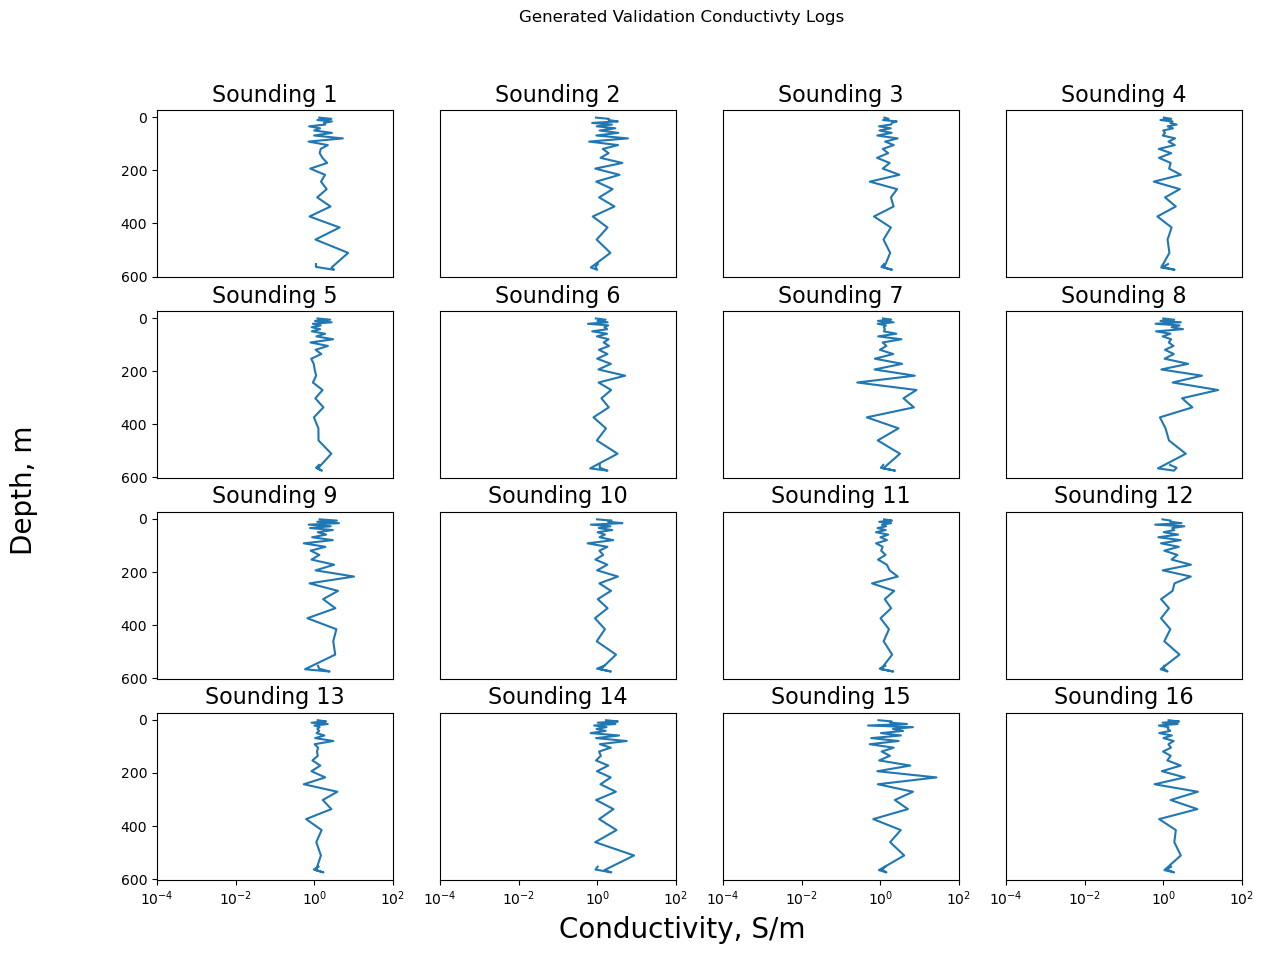

58286

<Figure size 640x480 with 0 Axes>

In [34]:
# plot a few random training models and their data
# vae.plot_complex(random_data, times=times, save2file=True, filename=run+'/training_MT_data.png')
vae.plot_logs(np.exp(network.tanhs_to_model(random_train)), depths=depths, save2file=True, 
              filename=run + '/training_models.png')

# Save starting plots
network.plot_models(save2file=True,folder=run,samples=zd_input.shape[0],
                    latent=zd_input,step=0)
# network.plot_data(save2file=True,folder=run,latent=zd_input,step=0)
# network.plot_residuals(save2file=True,folder=run,latent=zd_input,step=0)

plt.close('all')
plt.clf()
gc.collect()

In [35]:
# optimizer = tf.keras.optimizers.Adam(0.005, 0.5, clipnorm=1)
base_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)
optimizer = tf.keras.mixed_precision.LossScaleOptimizer(base_optimizer)


# Train

In [36]:
epochs = 100

In [37]:
validate_terms = []
train_terms = []
train_losses = []
ttest_losses = []
# print(len(train_dataset))
for epoch in range(1, epochs + 1):
    start_time = time.time()
#     print(train_dataset)
#     print(optimizer)
    beta = min(1.0, epoch / 50.0)
    for train_x in train_dataset:#.batch(BATCH_SIZE):
        # print(train_x)
        # tf.config.run_functions_eagerly(True)
        # z_mean, z_logvar = network.encode(train_x)
        # print(z_mean.dtype, z_logvar.dtype)
        train_loss, train_term = vae.compute_apply_gradients(network, train_x, optimizer, beta, 
                                    use_data_misfit=True)
        #train_losses.append(train_loss.numpy())
        train_terms.append([tt.numpy() for tt in train_term])
        train_losses.append(train_loss)
#         for test_x in test_dataset:
#             ttest_loss = vae.compute_losses(network, test_x)
#             terms = [loss(l).numpy() for l in ttest_loss]
#             ttest_losses.append(terms)
    end_time = time.time()

    # compute and save losses
    for val_x in validate_dataset:#.batch(BATCH_SIZE):
        val_loss, val_term = vae.compute_loss(network, val_x, beta)
        #terms = [tf.reduce_mean(l).numpy() for l in losses]
        #loss(vae.compute_reconstruction_loss(network, test_x))
    #elbo = -loss.result()
    validate_terms.append([tt.numpy() for tt in val_term])

    # CVAE print function
    print('Epoch: {}, Data misfit: {:.4}, '
          'Reconstruction: {:.4}, '
          'KL: {:.4}, '
          'Elapsed {:.4} s'.format(epoch, train_term[0], train_term[1], train_term[2],
                                #elbo,
                                end_time - start_time))

    # VAE print function
    # print('Epoch: {}, '
    #       'Reconstruction: {:.4}, '
    #       'KL: {:.4}, '
    #       'Elapsed {:.4} s'.format(epoch, train_term[0], train_term[1],
    #                             #elbo,
    #                             end_time - start_time))
    print('loss', train_loss)
    print('beta', beta)
        
    if epoch % 1e3 == 0:
        network.plot_models(save2file=True,folder=run,samples=zd_input.shape[0],
                 latent=zd_input,step=epoch)
        network.plot_data(save2file=True,folder=run,latent=zd_input,step=epoch)
        network.plot_residuals(save2file=True,folder=run,latent=zd_input,step=epoch)
        plt.close('all')
        gc.collect()

network.inference_net.save(run+'/encoder.h5')
network.generative_net.save(run+'/decoder.h5')
#np.save(run+'/optimizer_weights.npy', optimizer.load_weights())
# np.save(run+'/losses.npy', np.array(validate_terms))
# np.save(run+'/train_losses.npy', np.array(train_terms))


Epoch: 1, Data misfit: 3.823e+03, Reconstruction: 5.497e+03, KL: -9.843e-05, Elapsed 228.0 s
loss tf.Tensor(9320.599, shape=(), dtype=float32)
beta 0.02
Epoch: 2, Data misfit: 6.58e+03, Reconstruction: 2.238e+03, KL: 0.004387, Elapsed 245.6 s
loss tf.Tensor(8817.844, shape=(), dtype=float32)
beta 0.04
Epoch: 3, Data misfit: 1.212e+03, Reconstruction: 469.4, KL: 0.05926, Elapsed 232.0 s
loss tf.Tensor(1681.7982, shape=(), dtype=float32)
beta 0.06
Epoch: 4, Data misfit: 952.4, Reconstruction: 426.7, KL: 0.1111, Elapsed 231.4 s
loss tf.Tensor(1379.2366, shape=(), dtype=float32)
beta 0.08
Epoch: 5, Data misfit: 1.062e+03, Reconstruction: 415.5, KL: 0.1941, Elapsed 233.2 s
loss tf.Tensor(1478.0857, shape=(), dtype=float32)
beta 0.1
Epoch: 6, Data misfit: 947.5, Reconstruction: 498.7, KL: 0.2697, Elapsed 232.3 s
loss tf.Tensor(1446.4747, shape=(), dtype=float32)
beta 0.12
Epoch: 7, Data misfit: 739.5, Reconstruction: 280.5, KL: 0.3786, Elapsed 230.1 s
loss tf.Tensor(1020.3753, shape=(), dtyp

c:\Users\saraf\anaconda3\envs\simpeg\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Load networks

In [38]:
network.inference_net = tf.keras.models.load_model(run+'/encoder.h5')
network.generative_net = tf.keras.models.load_model(run+'/decoder.h5')

In [39]:
loss_terms = np.load(run+'/losses.npy')

In [40]:
#optimizer_weights = np.load(run+'/optimizer_weights.npy', allow_pickle=True)

https://stackoverflow.com/questions/49503748/save-and-load-model-optimizer-state to train more

# Plot loss over epochs

In [41]:
plt.rcParams.update({'font.size': 18})

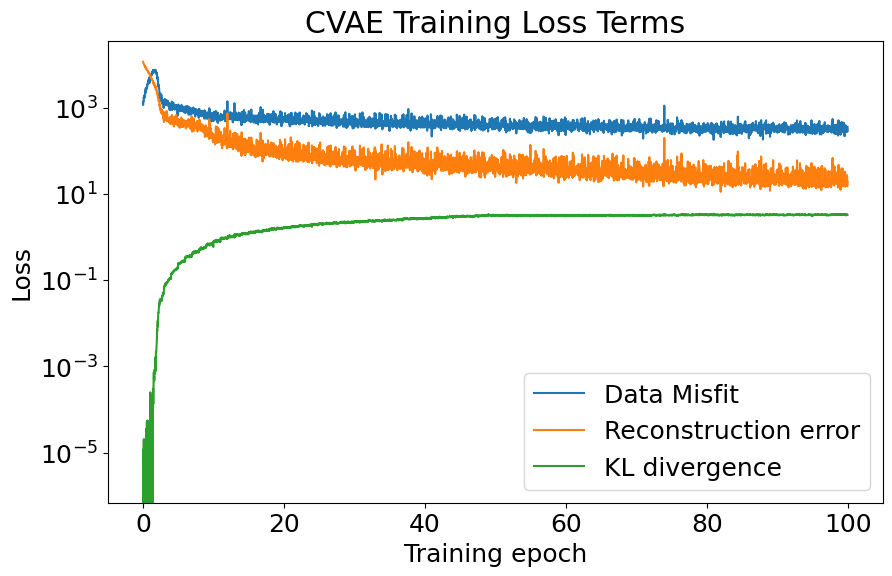

In [88]:
tt = np.array(train_terms)
batches_per_epoch = tf.data.experimental.cardinality(train_dataset).numpy()
num_batches = tt.shape[0]
plt.figure(figsize=(10,6))
plt.semilogy(np.arange(num_batches)/batches_per_epoch, tt)
plt.ylabel('Loss')
plt.xlabel('Training epoch')
plt.title("CVAE Training Loss Terms")
plt.legend(['Data Misfit','Reconstruction error', 'KL divergence'])
plt.savefig('training_loss_'+run+'_w.png')
plt.show()

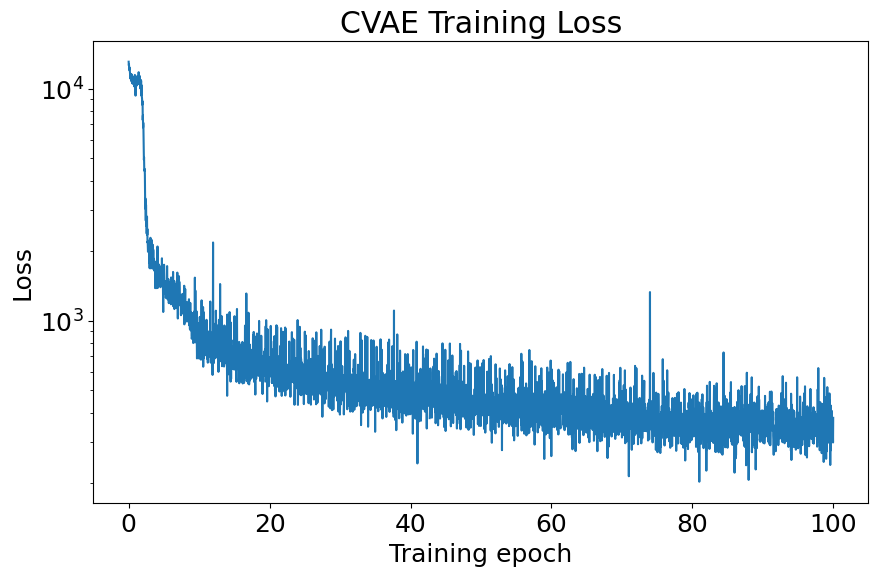

In [43]:
tl = np.array(train_losses)
batches_per_epoch = tf.data.experimental.cardinality(train_dataset).numpy()
num_batches = tt.shape[0]
plt.figure(figsize=(10,6))
plt.semilogy(np.arange(num_batches)/batches_per_epoch, tl)
plt.ylabel('Loss')
plt.xlabel('Training epoch')
plt.title("CVAE Training Loss")
# plt.legend(['Loss'])
plt.savefig('training_loss_'+run+'_w.png')
plt.show()

# View some tests

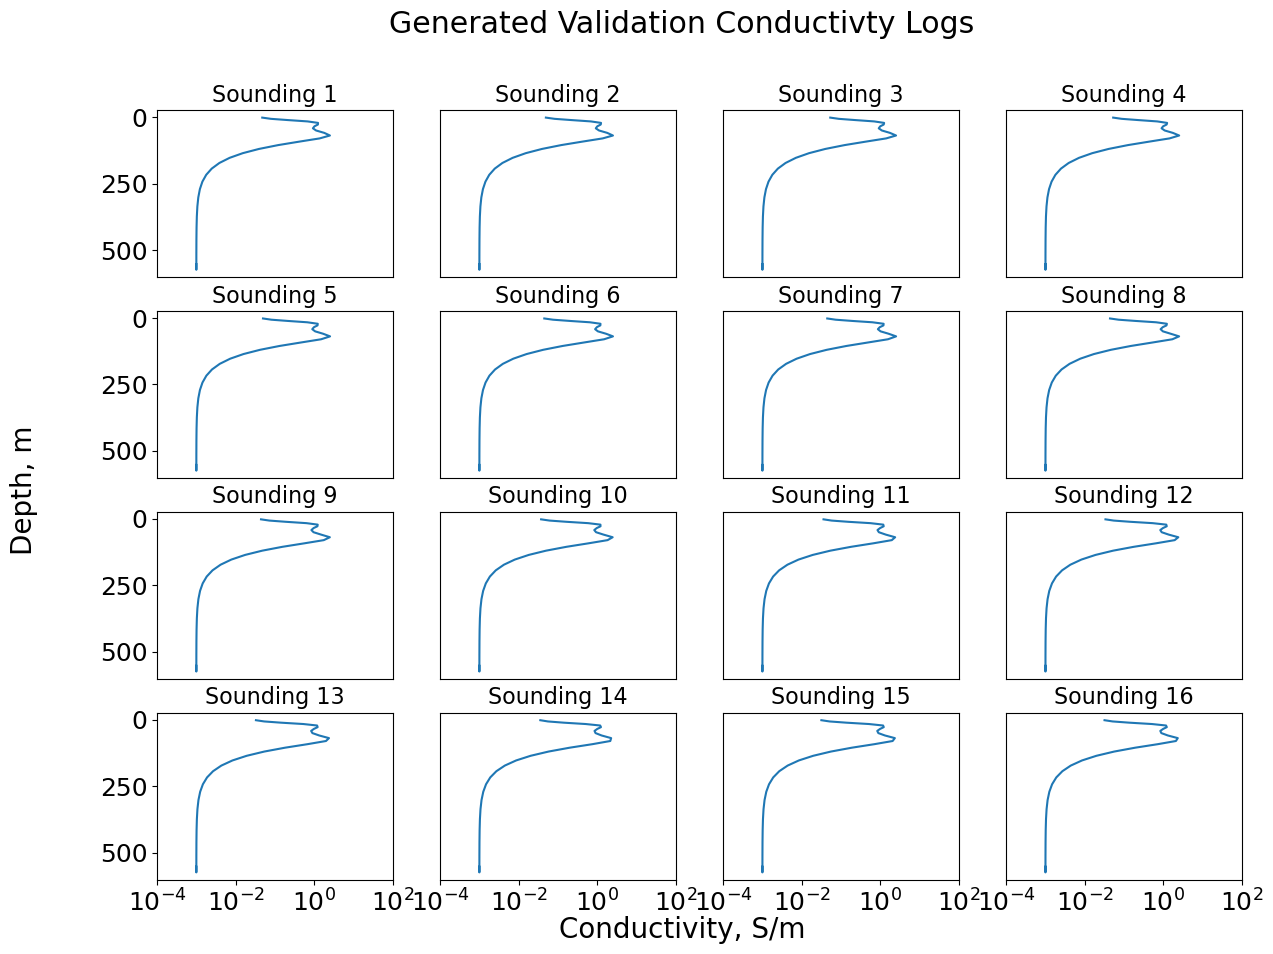

In [44]:
vae.plot_logs(np.exp(network.tanhs_to_model(x_validate[0:16])), depths=depths, step=16, save2file=False)

(16, 20)
(17419, 16)


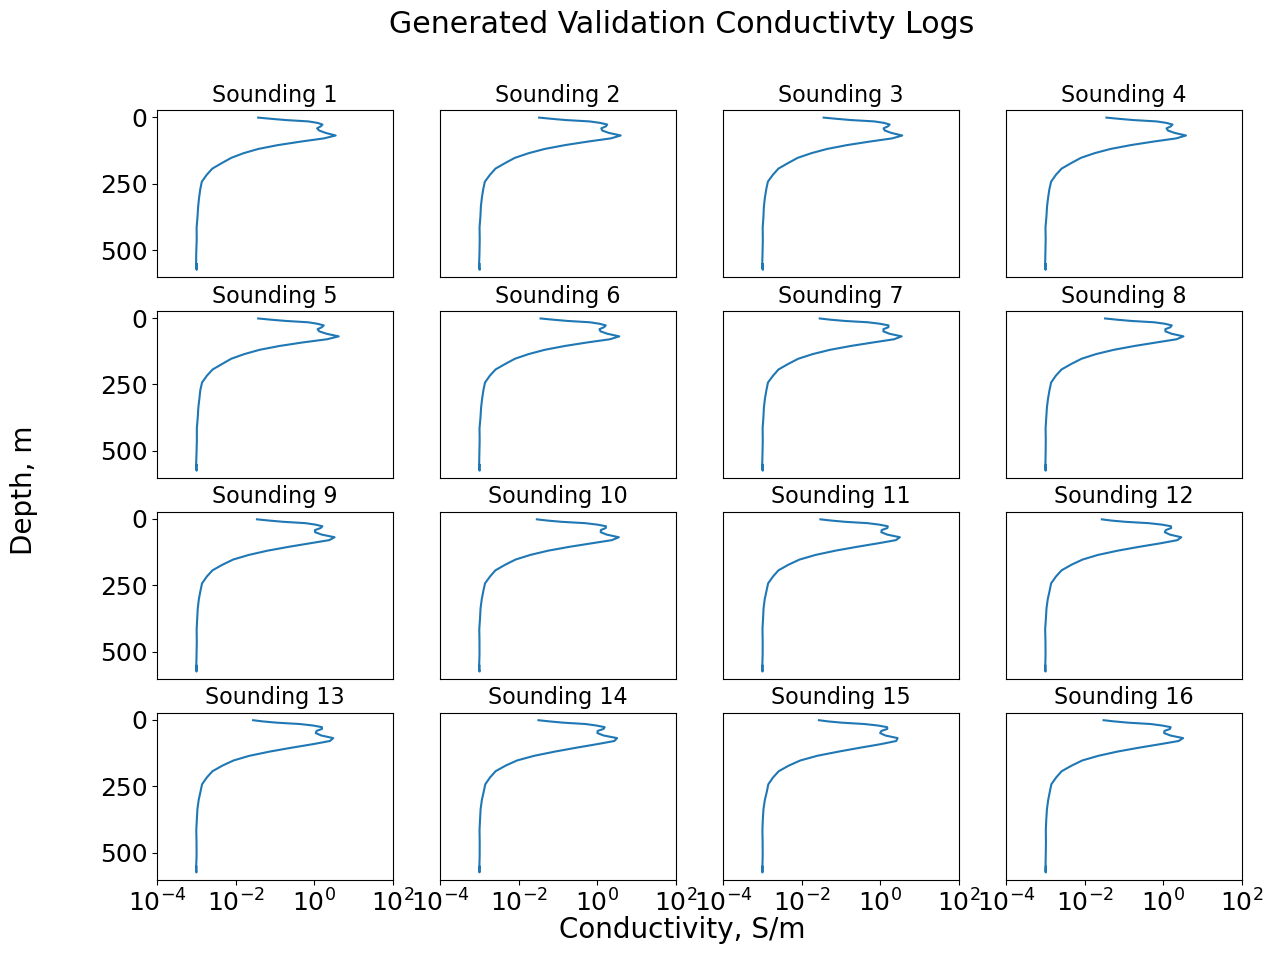

In [45]:
z_model = network.reparameterize(*network.encode(x_validate[:16]))
z_model_all = network.reparameterize(*network.encode(x_validate))
print(np.shape(z_model))
z_data = raw_validate_data[:16]
z_data_all = raw_validate_data
print(np.shape(z_data_all))
zmd = tf.concat((z_model,z_data),-1)
zmd_all= tf.concat((z_model_all,z_data_all),-1)
network.plot_models(latent=zmd)

In [46]:
depth_centers = (network.depths[1:] + network.depths[:-1])/2
plot_depths = np.r_[
    depth_centers[0] - (depth_centers[1] - depth_centers[0]),
    depth_centers,
    depth_centers[-1] + depth_centers[-1] - depth_centers[-2]
]

zmd_tanhs = network.decode(zmd, apply_tanh=True)
zmd_samples = zmd_tanhs.shape[0]
zmd_tanhs = np.reshape(zmd_tanhs, (zmd_samples, network.n_model))
zmd_logs = network.tanhs_to_model(zmd_tanhs)
# zmdlogs = np.exp(zmd_logs)

zmd_tanhs_all = network.decode(zmd_all, apply_tanh=True)
zmd_samples_all = zmd_tanhs_all.shape[0]
zmd_tanhs_all = np.reshape(zmd_tanhs_all, (zmd_samples_all, network.n_model))
zmd_logs_all = network.tanhs_to_model(zmd_tanhs_all)

true_validate = network.tanhs_to_model(x_validate[0:16])
true_validate_all = network.tanhs_to_model(x_validate)

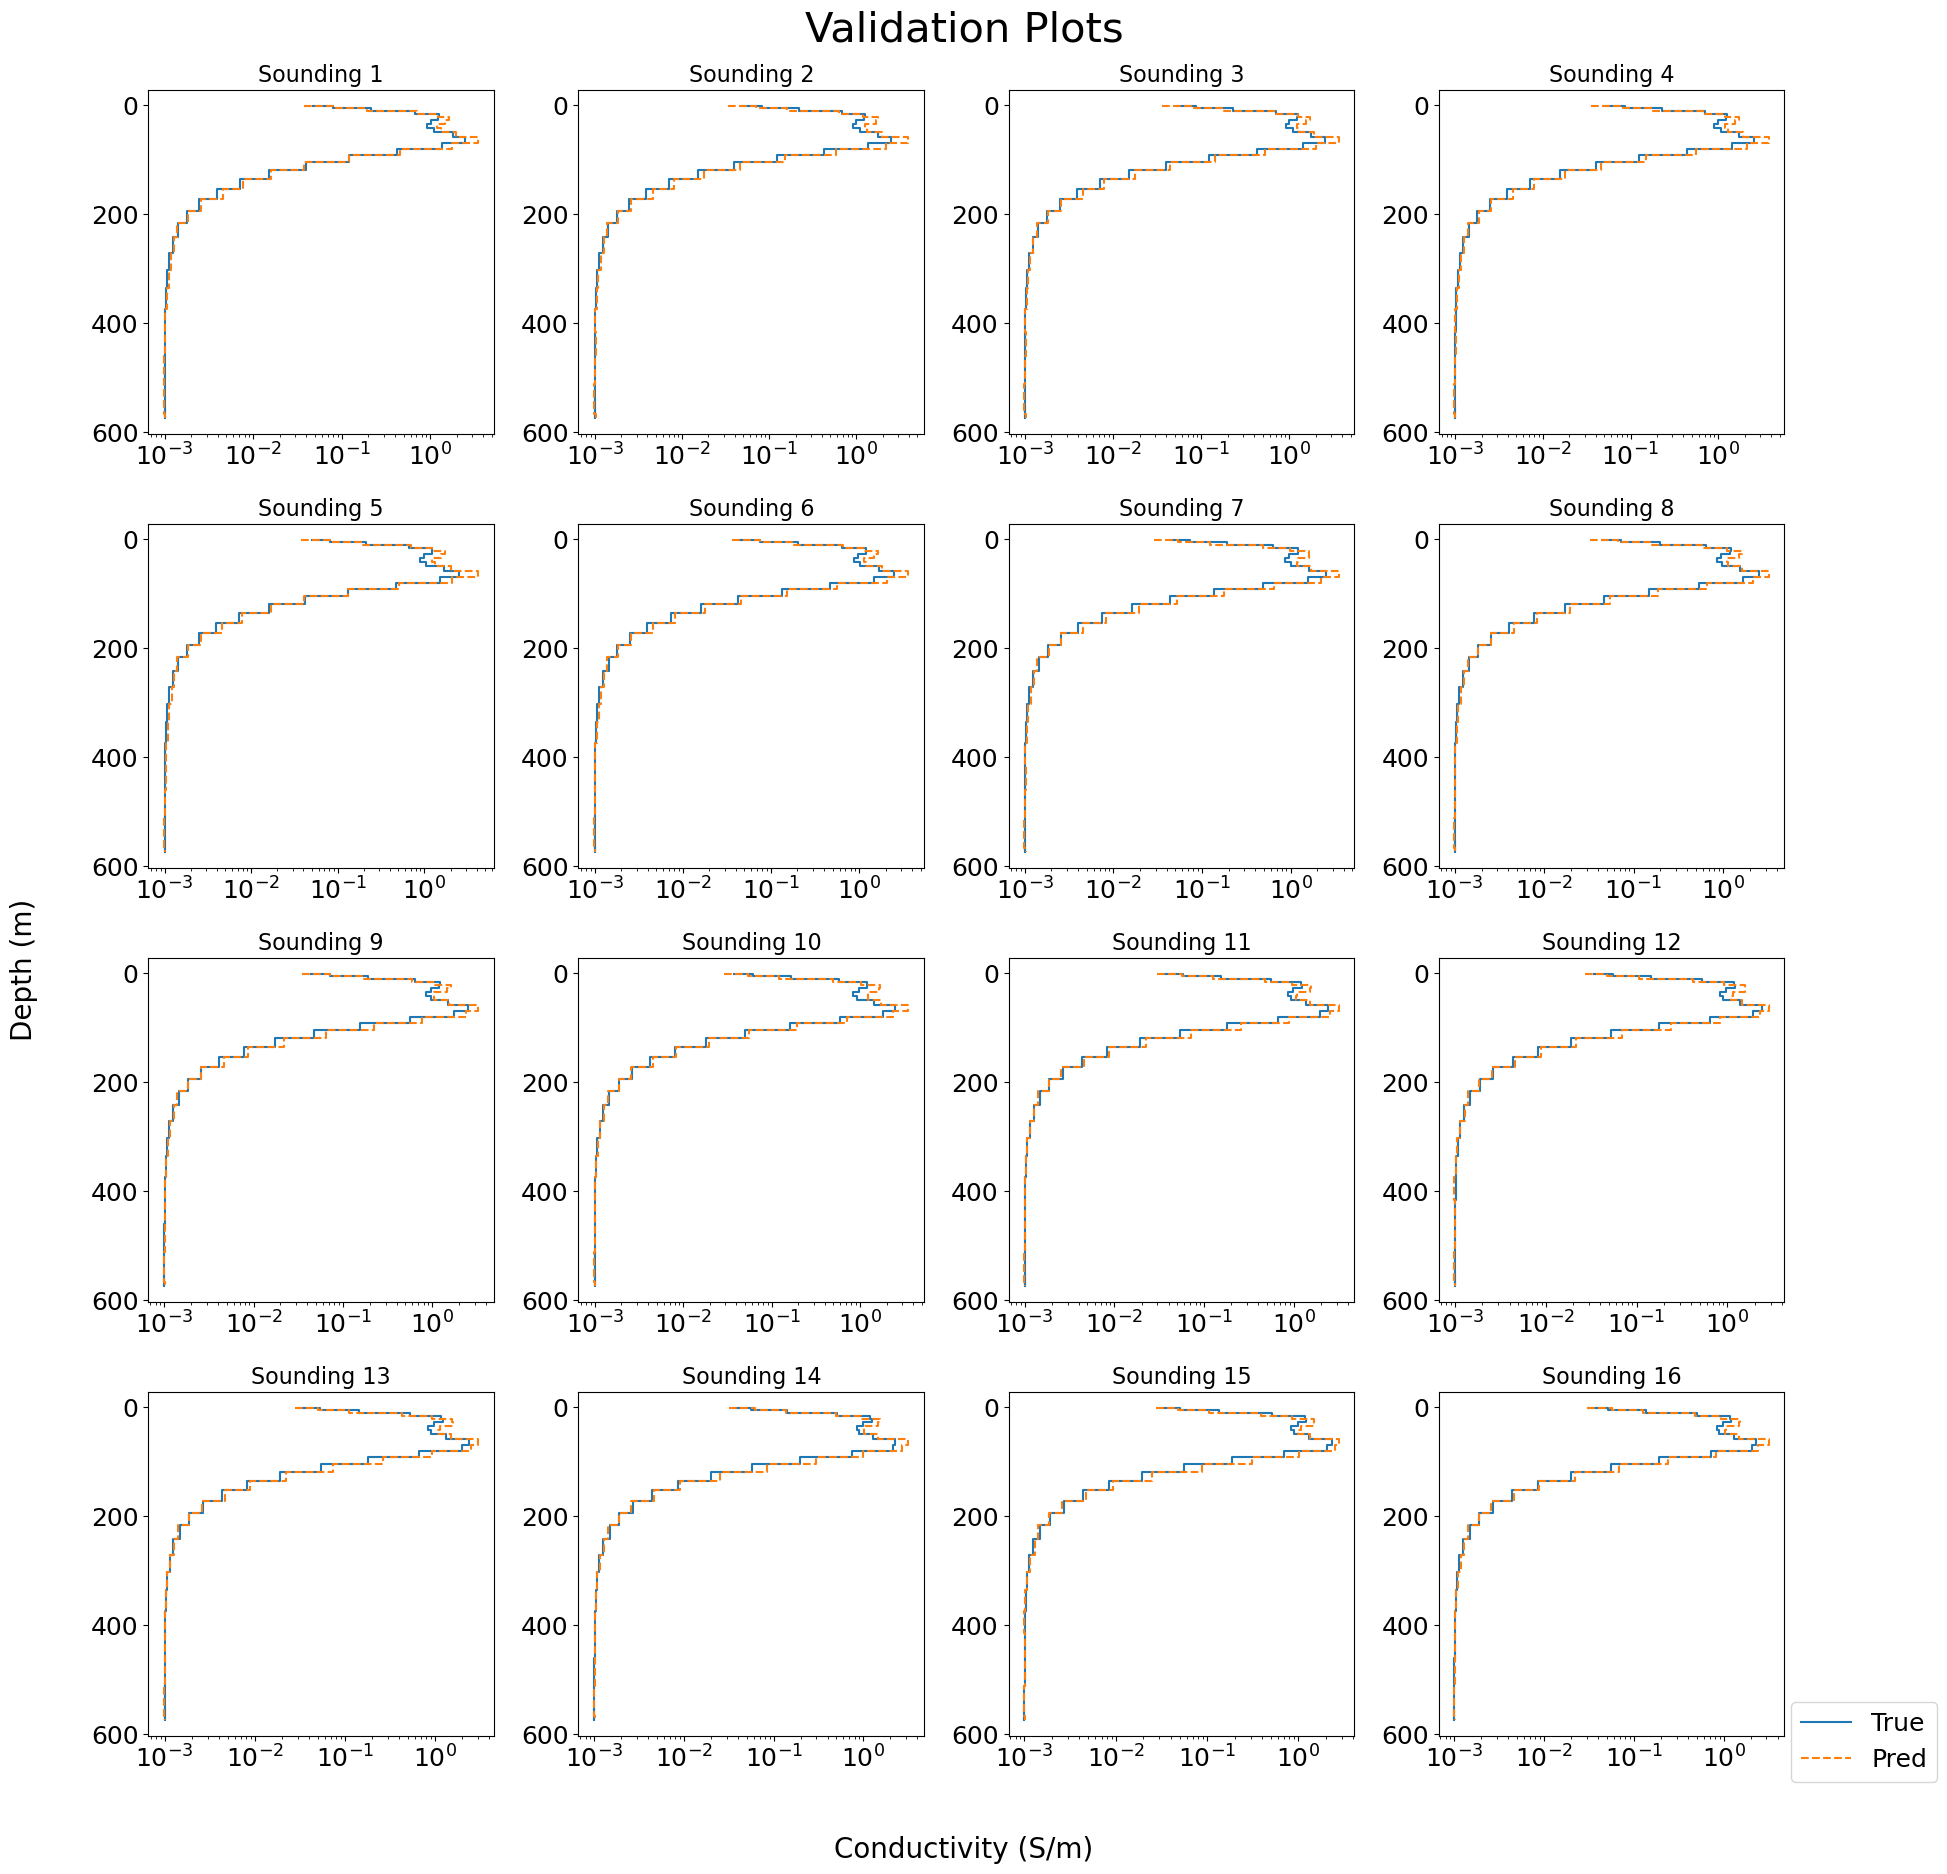

In [47]:
#Why does x2 on the predicted make it match better???
# fig = plt.figure(figsize=(20, 20))

# for i in range(16):
#     plt.subplot(4, 4, i + 1)
#     plt.plot(true_validate[i], plot_depths, drawstyle='steps-post', label='True')
#     plt.plot(zmd_logs[i][:-2], plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
#     # plt.xlabel('Conductivity (S/m)')
#     # plt.ylabel('Depth (m)')
#     plt.suptitle('True vs Predicted Conductivity Plots',fontsize = 30)
#     plt.xscale('log')
#     plt.gca().invert_yaxis()
#     if i == 0:
#         plt.legend()

# fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
# fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
#              rotation='vertical', size=20)
# fig.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 20))
# samples = data.shape[0]
subplot_rows = 4
subplot_cols = 4
for i in range(16):
        ax = plt.subplot(subplot_rows, subplot_cols, i+1)
        ax.set_title('Sounding %d' %int(i+1), fontsize = 16)
        ax.semilogx(np.exp(true_validate[i]), plot_depths, drawstyle='steps-post', label='True')
        ax.semilogx(np.exp(zmd_logs[i][:-2]), plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
        plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
             rotation='vertical', size=20)
plt.suptitle('Validation Plots',fontsize = 30)
plt.tight_layout(rect=(0.05,0.08,1,1))
plt.show()

In [48]:
def minmax(x): return tf.reduce_min(x), tf.reduce_max(x)

In [49]:
import numpy as np

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def r2_score(a, b):
    ss_res = np.sum((a - b) ** 2)
    ss_tot = np.sum((a - np.mean(a)) ** 2)
    return 1 - ss_res / ss_tot

In [50]:
model_rmse_v = rmse(zmd_logs, np.squeeze(true_validate))
model_mae_v = mae(zmd_logs, np.squeeze(true_validate))
model_r2_v = r2_score(zmd_logs.flatten(), np.squeeze(true_validate).flatten())

layer_rmse_v = np.sqrt(np.mean((zmd_logs- np.squeeze(true_validate)) ** 2, axis=0))

print("Layer-wise RMSE shape:", layer_rmse_v)  # (32,)

print("Model RMSE:", model_rmse_v, np.log(np.exp(model_rmse_v)))
print("Model MAE:", model_mae_v)
print("Model R2:", model_r2_v)

Layer-wise RMSE shape: [0.272043   0.11989923 0.2373658  0.1427364  0.17427438 0.2929196
 0.44985921 0.28391274 0.17402393 0.10421716 0.33527976 0.29519611
 0.24558203 0.27528981 0.23758739 0.15389253 0.08693988 0.1180139
 0.03195714 0.02171667 0.04021609 0.02189148 0.03339697 0.02718407
 0.02535225 0.0128678  0.01468328 0.0093393  0.01504093 0.01280279
 0.01586271 0.01842821]
Model RMSE: 0.1811593934068667 0.18115939340686665
Model MAE: 0.124284598822389
Model R2: 0.9965466778732082


In [51]:
tanhs = network.decode(zmd, apply_tanh=True)
minmax(tanhs)
print(tanhs)

tf.Tensor(
[[[-2.56622553e-01]
  [-1.95972785e-01]
  [-1.29369825e-01]
  [-2.66076457e-02]
  [ 1.52268428e-02]
  [ 3.76024731e-02]
  [ 2.98400074e-02]
  [ 1.29965106e-02]
  [ 2.20730156e-02]
  [ 5.16393371e-02]
  [ 9.80524346e-02]
  [ 4.38398011e-02]
  [-6.11727647e-02]
  [-1.66025668e-01]
  [-2.55963713e-01]
  [-3.23533833e-01]
  [-3.79866719e-01]
  [-4.22224075e-01]
  [-4.66653943e-01]
  [-4.92382854e-01]
  [-5.14696002e-01]
  [-5.21856308e-01]
  [-5.27148247e-01]
  [-5.31494975e-01]
  [-5.34462035e-01]
  [-5.38632929e-01]
  [-5.38243830e-01]
  [-5.40382683e-01]
  [-5.41106343e-01]
  [-5.38292050e-01]
  [-5.37805140e-01]
  [-5.37393808e-01]]

 [[-2.66259521e-01]
  [-2.08391681e-01]
  [-1.43292829e-01]
  [-3.53747420e-02]
  [ 1.32595934e-02]
  [ 4.53022234e-02]
  [ 3.96775976e-02]
  [ 1.84234120e-02]
  [ 2.23416090e-02]
  [ 5.24068475e-02]
  [ 1.07387781e-01]
  [ 6.15910254e-02]
  [-4.32685539e-02]
  [-1.47113964e-01]
  [-2.40491197e-01]
  [-3.14150691e-01]
  [-3.77331823e-01]
  [-4.2

In [52]:
minmax(x_test[0:16])

(<tf.Tensor: shape=(), dtype=float64, numpy=-0.5399266299885006>,
 <tf.Tensor: shape=(), dtype=float64, numpy=0.03254183984457575>)

(16, 36)


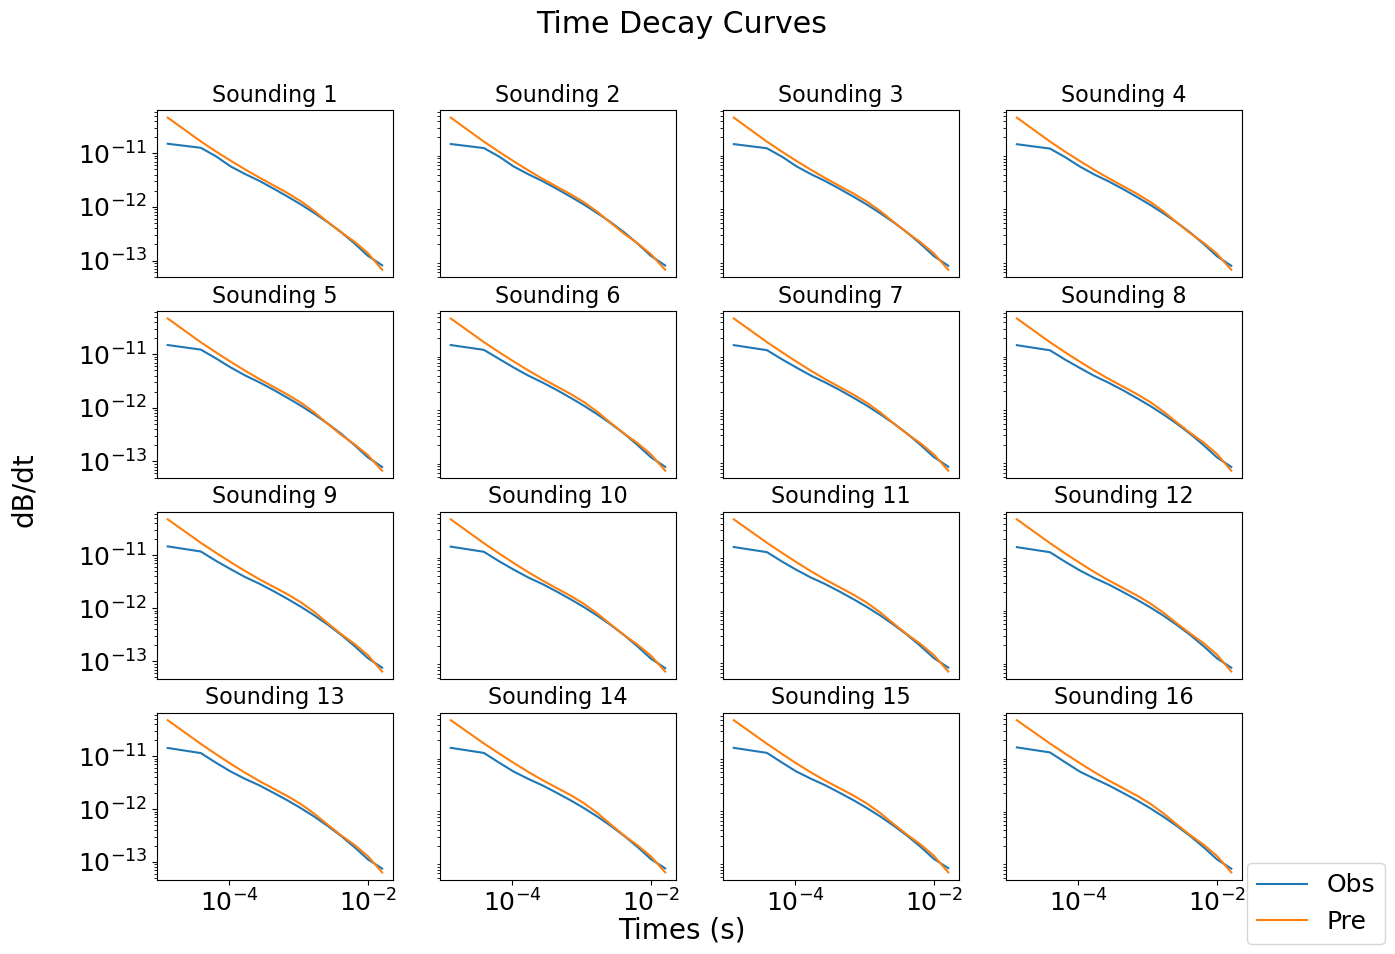

In [53]:
print(zmd.shape)
network.plot_data(latent=zmd)

# d_obs is from validation seta

d_obs: (16, 16)
d_pre: (16, 16)
data_std: (1, 32, 1)
n_time: 16
d_std: (1, 16)
data tf.Tensor(
[[-3.11822651e-11 -3.98020158e-12 -2.01591348e-12 -1.60780981e-12
  -9.02400116e-13 -4.60057339e-13 -3.27390892e-13 -2.47947604e-13
  -1.58053258e-13 -6.82081887e-14 -5.85870328e-15 -3.47974687e-16
  -1.64626207e-14 -1.53819828e-14 -1.41891639e-14 -1.42232756e-14]
 [-3.13879339e-11 -4.00236181e-12 -1.95449299e-12 -1.44956573e-12
  -7.50624823e-13 -3.18376402e-13 -2.09540068e-13 -1.68773741e-13
  -1.13055615e-13 -4.47500110e-14 -1.21860529e-14 -1.99987325e-14
  -2.00178958e-15 -9.89857610e-15 -1.36628380e-14 -1.36963195e-14]
 [-3.13328738e-11 -4.07361384e-12 -2.02858997e-12 -1.47845711e-12
  -8.33561952e-13 -4.04717709e-13 -2.77572236e-13 -2.21587288e-13
  -1.51273959e-13 -7.18008552e-14 -9.08962575e-15 -2.11885631e-15
  -1.39211152e-14 -1.49166839e-14 -1.27493705e-14 -1.27829333e-14]
 [-3.16519033e-11 -4.33606883e-12 -2.24295495e-12 -1.53500129e-12
  -8.78955329e-13 -4.33885566e-13 -2.8958497

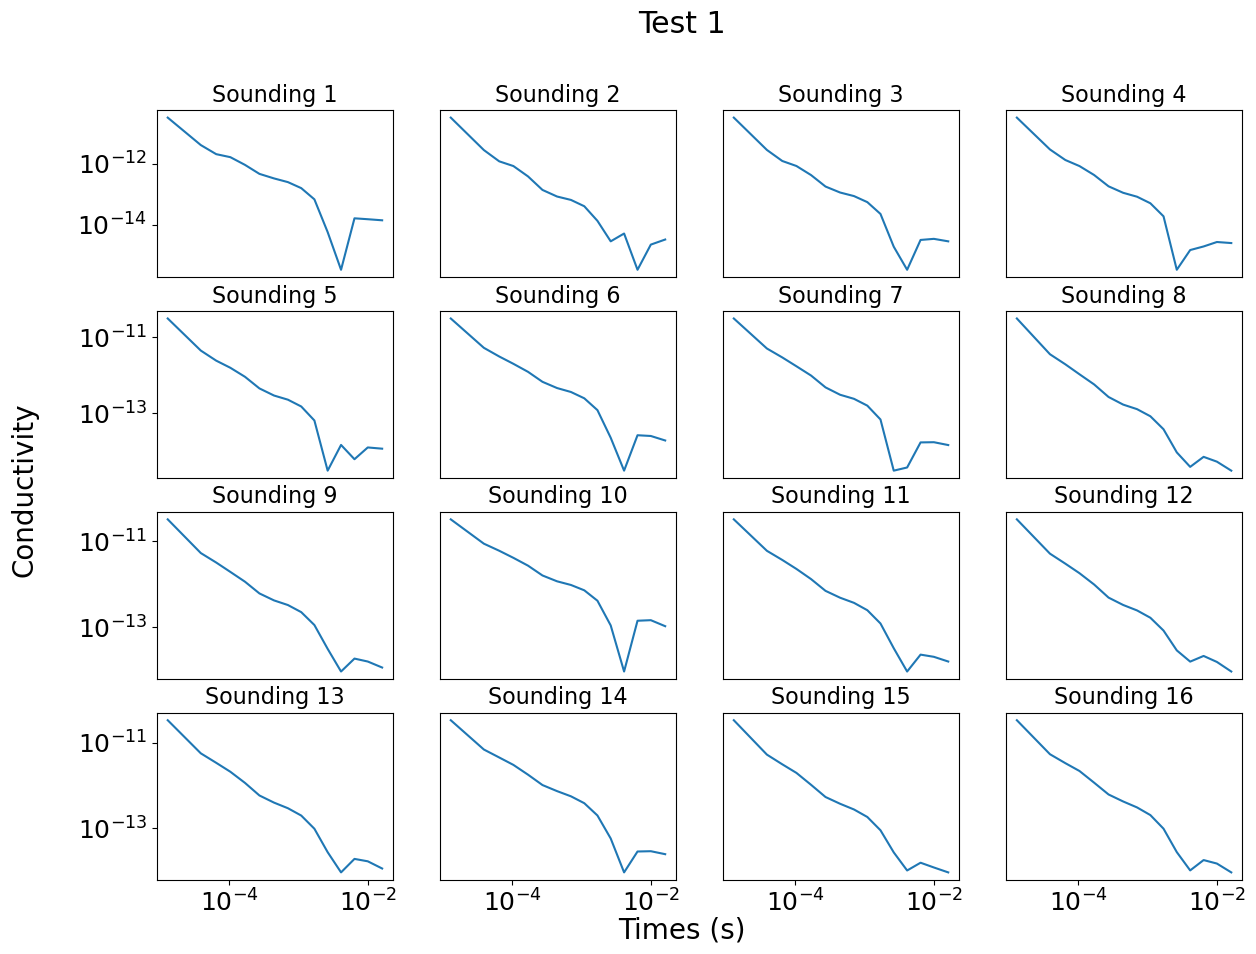

In [54]:
network.plot_residuals(latent=zmd, weighted=False, step=15)

In [55]:
# Trim everything consistently
true_section_v = true_validate_all[:, :-2]
pred_section_v = zmd_logs_all[:, :-2]
depths_2d = plot_depths[:-2]

# Transpose → (depth, distance)
true_section_v = true_section_v.T
true_section_v = np.squeeze(true_section_v)
pred_section_v = pred_section_v.T
pred_section_v = np.squeeze(pred_section_v)

nx_v = true_section_v.shape[1]
x_v = np.arange(nx_v)   # or real station distances if you have them

X_v, Z_v = np.meshgrid(x_v, depths_2d)
print(X_v.shape,Z_v.shape)

(30, 17419) (30, 17419)


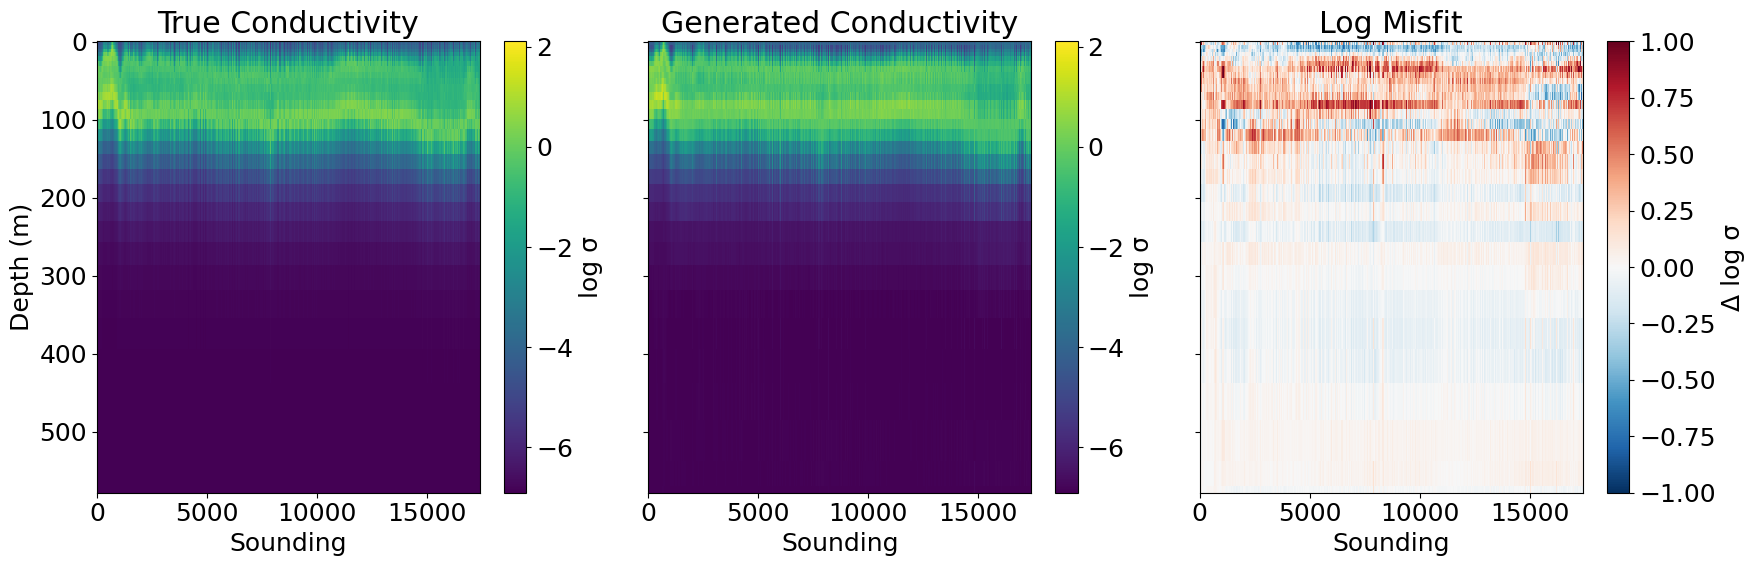

In [56]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Use same color limits for fair comparison
vmin = np.min(true_section_v)
vmax = np.max(true_section_v)

# TRUE
im0 = axs[0].pcolormesh(X_v, Z_v, true_section_v,
                        shading='auto', cmap='viridis',
                        vmin=vmin, vmax=vmax)
axs[0].set_title('True Conductivity')

# PREDICTED
im1 = axs[1].pcolormesh(X_v, Z_v, pred_section_v,
                        shading='auto', cmap='viridis',
                        vmin=vmin, vmax=vmax)
axs[1].set_title('Generated Conductivity')

# MISFIT (log difference)
misfit = pred_section_v - true_section_v

im2 = axs[2].pcolormesh(X_v, Z_v, misfit,
                        shading='auto', cmap='RdBu_r',
                        vmin=-1, vmax=1)  # adjustable
axs[2].set_title('Log Misfit')

# Formatting
for ax in axs:
    ax.invert_yaxis()
    ax.set_xlabel('Sounding')

axs[0].set_ylabel('Depth (m)')

# Colorbars
fig.colorbar(im0, ax=axs[0], label='log σ')
fig.colorbar(im1, ax=axs[1], label='log σ')
fig.colorbar(im2, ax=axs[2], label='Δ log σ')

plt.tight_layout()
plt.show()

# Randomize latent; does data still fit?

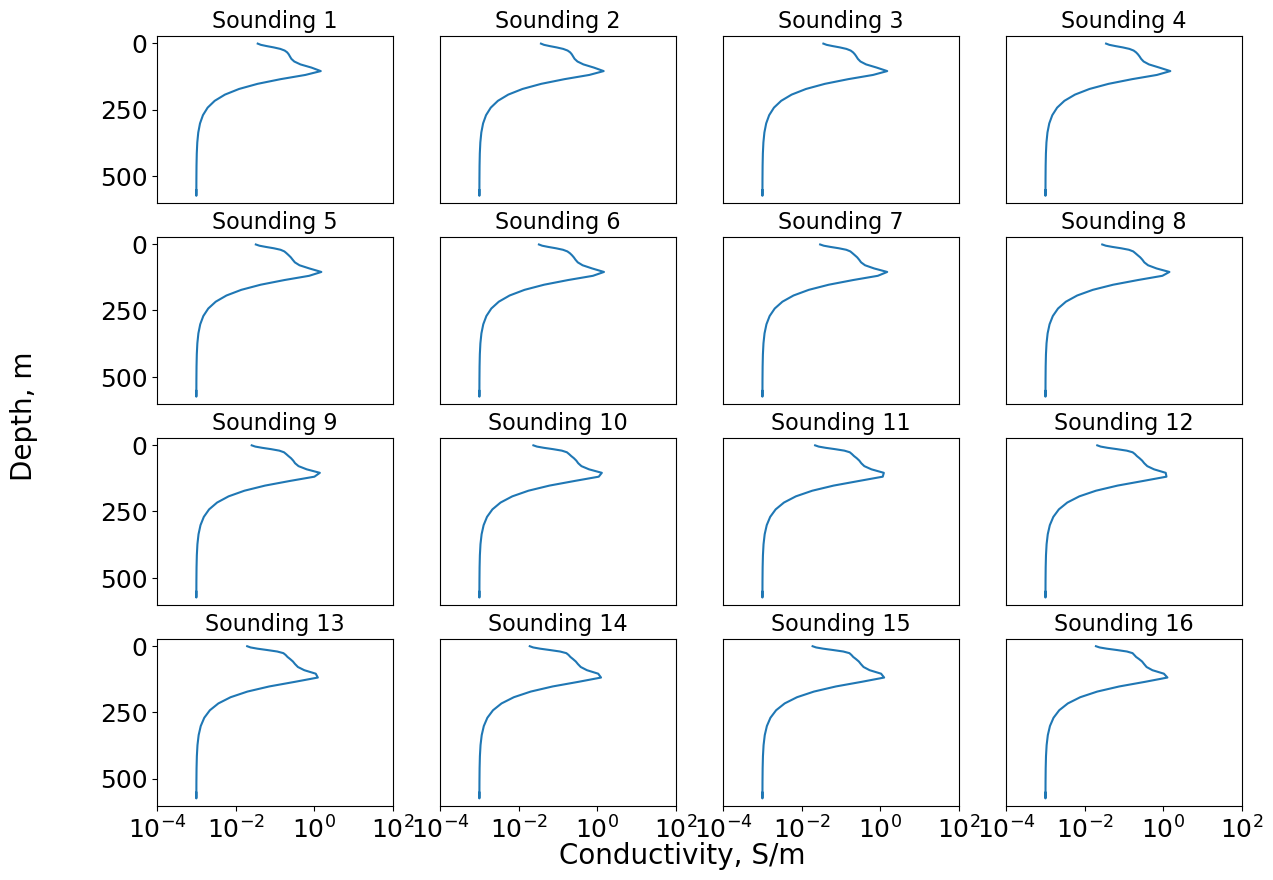

In [57]:
vae.plot_logs(np.exp(network.tanhs_to_model(x_test[0   :16])), depths=depths)

In [58]:
print(x_test[0:1,:,0].shape)
print(z_data[0:1].shape)

(1, 32)
(1, 16)


In [123]:
# data0 = tf.tile(z_data[0:1],[16,1])
data0 = tf.tile(raw_test_data[0:1],[16,1])
# data0= np.log(data0)
# data0_all = tf.tile(z_data_all[0:1][])
# print(latent_input)
data0 = tf.cast(data0, tf.float32)
# print(data0)
zmd2 = tf.concat((latent_input,data0),-1)
# print(zmd2)

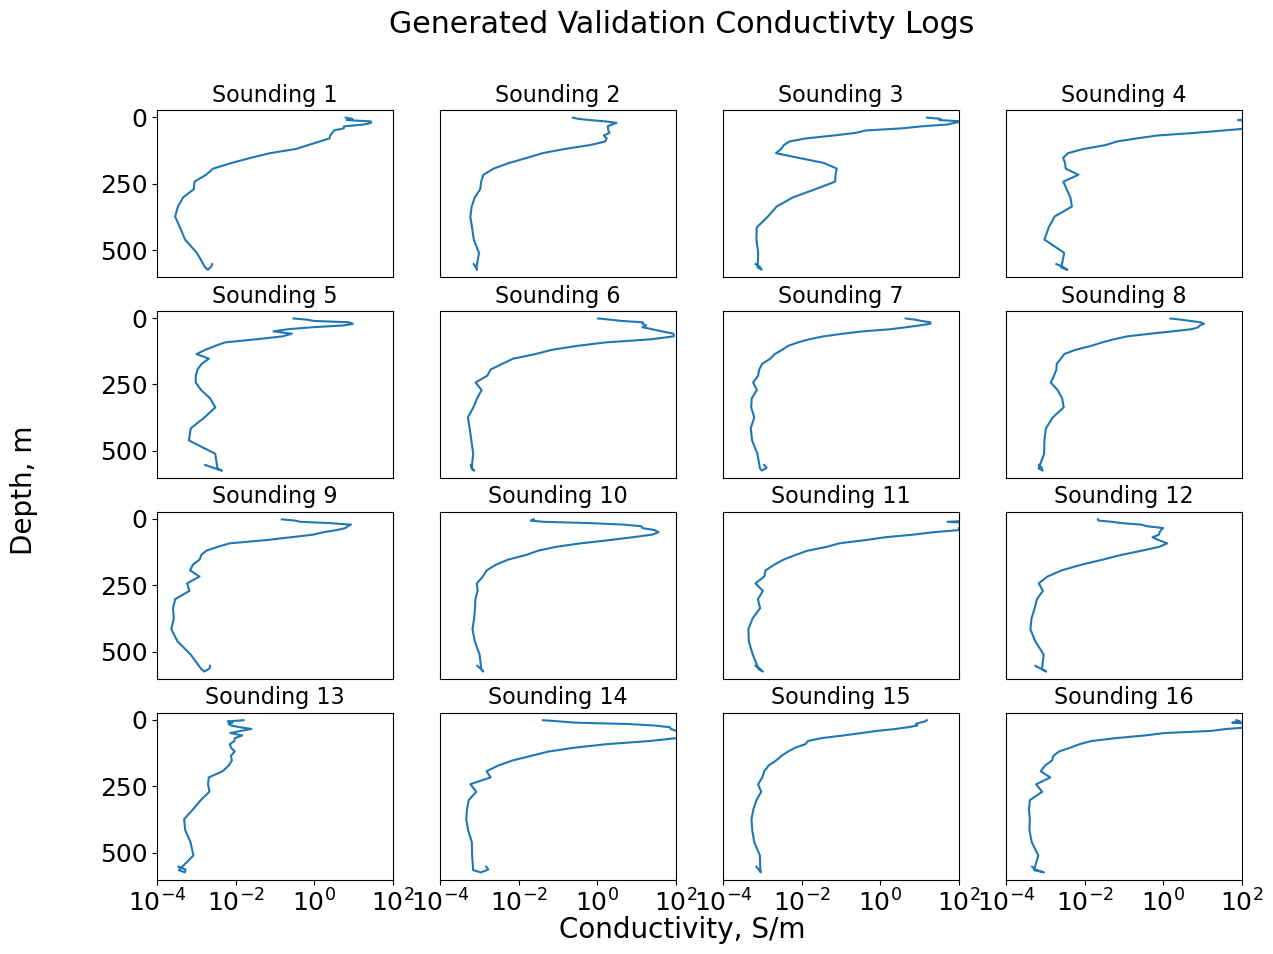

In [124]:
network.plot_models(latent=zmd2)

In [125]:
zmd2_tanhs = network.decode(zmd2, apply_tanh=True)
zmd2_samples = zmd2_tanhs.shape[0]
zmd2_tanhs = np.reshape(zmd2_tanhs, (zmd2_samples, network.n_model))
zmd2_logs = network.tanhs_to_model(zmd2_tanhs)
print(np.shape(zmd2_logs))
# zmd2 = (10**zmd2_logs)-1


# true_test = tf.tile(x_test[0:1,:,0],[16,1])
# true_test = tf.cast(true_test, tf.float32)
true_test1 = network.tanhs_to_model(x_test[0   :16])
true_test1_all = network.tanhs_to_model(x_test)
# true_test1 = (10**true_test1)-1
print(true_test1)

(16, 32)
[[[-3.31088202]
  [-3.12918755]
  [-2.79267944]
  [-2.37157961]
  [-1.98730804]
  [-1.7325936 ]
  [-1.5877366 ]
  [-1.49473695]
  [-1.42336797]
  [-1.33915432]
  [-1.17041972]
  [-0.80862201]
  [-0.1648099 ]
  [ 0.3823309 ]
  [-0.52120413]
  [-1.97625338]
  [-3.31956809]
  [-4.40550654]
  [-5.23106628]
  [-5.82970427]
  [-6.24452518]
  [-6.51871973]
  [-6.69096708]
  [-6.79341907]
  [-6.85087224]
  [-6.88111724]
  [-6.89600755]
  [-6.90283938]
  [-6.90572833]
  [-6.90675378]
  [-6.90603365]
  [-6.90637143]]

 [[-3.2988651 ]
  [-3.12247193]
  [-2.79401193]
  [-2.37975246]
  [-1.99775686]
  [-1.74067765]
  [-1.59130825]
  [-1.49309547]
  [-1.41607792]
  [-1.32819339]
  [-1.16155401]
  [-0.81343432]
  [-0.20035702]
  [ 0.37471926]
  [-0.46860285]
  [-1.92662501]
  [-3.28337915]
  [-4.38100636]
  [-5.21524209]
  [-5.81994917]
  [-6.23882395]
  [-6.51559631]
  [-6.68939354]
  [-6.79271467]
  [-6.8506172 ]
  [-6.88106856]
  [-6.89603918]
  [-6.90289113]
  [-6.90578223]
  [-6.9068167

In [126]:
zmd2_logs.shape

(16, 32)

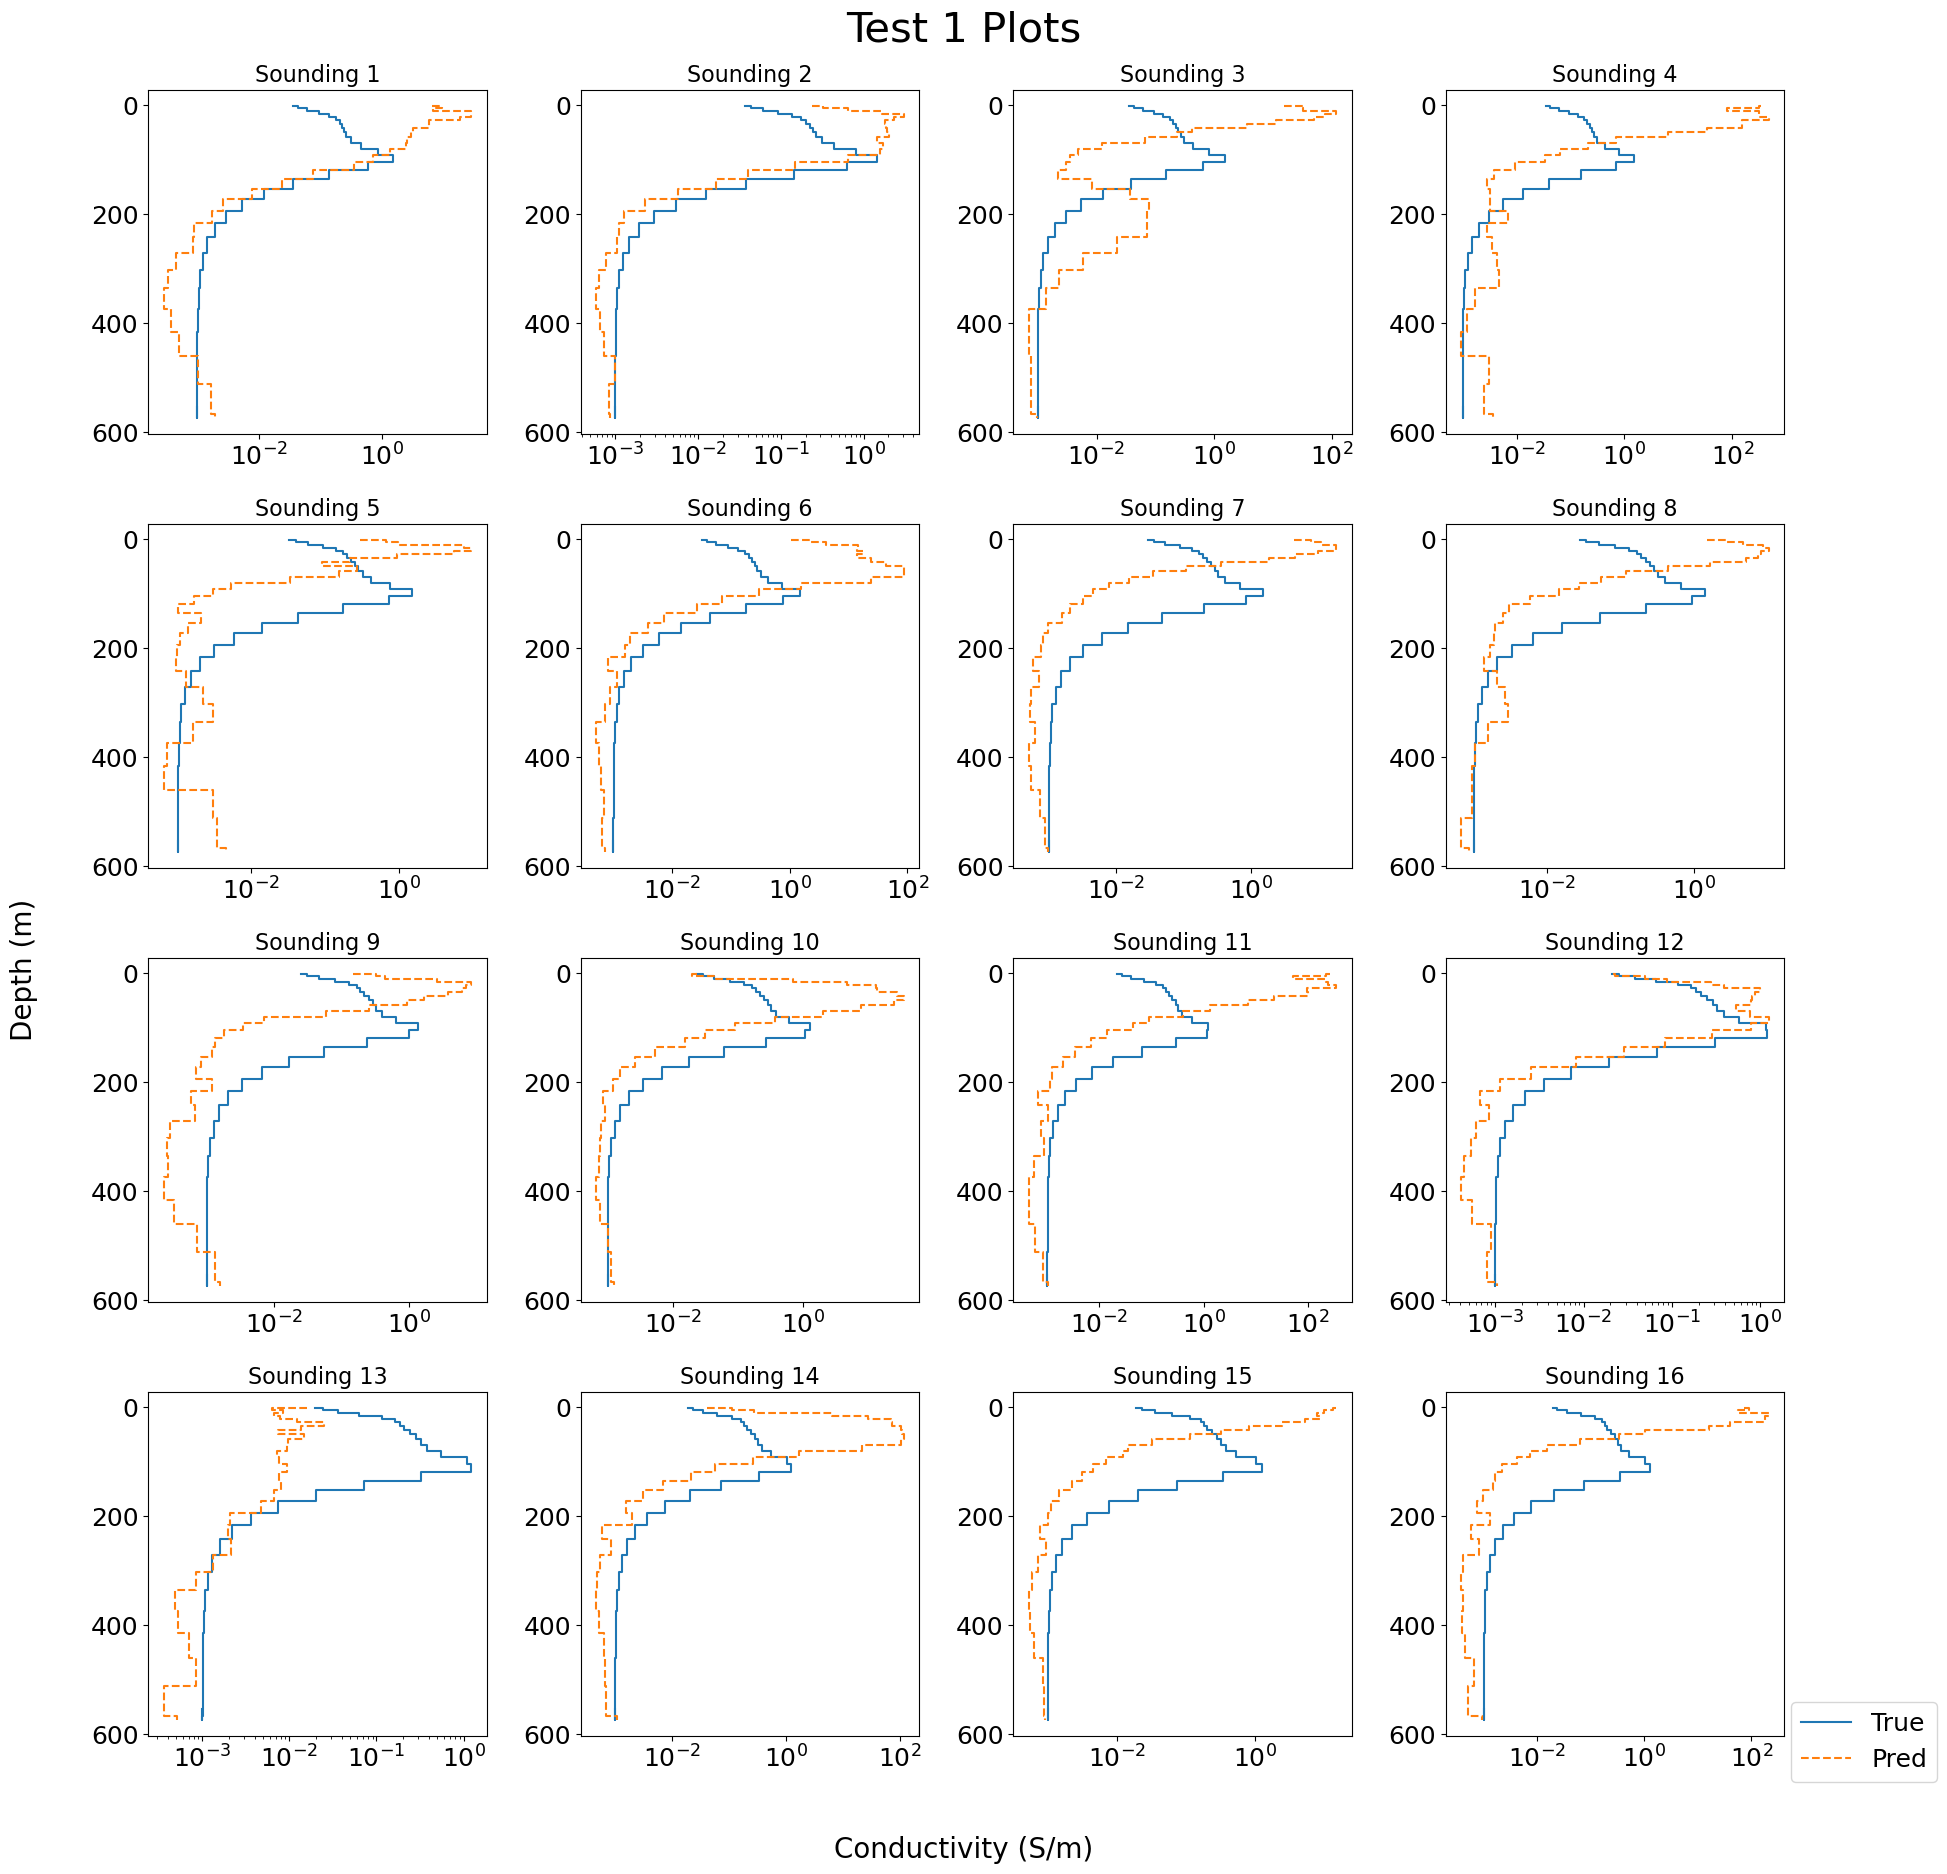

In [127]:
# plt.figure(figsize=(20, 20))

# for i in range(16):
#     plt.subplot(4, 4, i + 1)
#     plt.plot(true_test1[i], plot_depths, drawstyle='steps-post', label='True')
#     plt.plot(np.exp(zmd2_logs[i][:-2]), plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
#     plt.xscale('log')
#     # plt.plot(zmd2_logs[i], plot_depths, label='Pred_logs', linestyle='--')
#     plt.gca().invert_yaxis()
#     if i == 0:
#         plt.legend()
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 20))
# samples = data.shape[0]
subplot_rows = 4
subplot_cols = 4
for i in range(16):
        ax = plt.subplot(subplot_rows, subplot_cols, i+1)
        ax.set_title('Sounding %d' %int(i+1), fontsize = 16)
        ax.semilogx(np.exp(true_test1[i]), plot_depths, drawstyle='steps-post', label='True')
        ax.semilogx(np.exp(zmd2_logs[i][:-2]), plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
        plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
             rotation='vertical', size=20)
plt.suptitle('Test 1 Plots',fontsize = 30)
plt.tight_layout(rect=(0.05,0.08,1,1))
plt.show()

In [128]:
#apply np.exp and log to zmd_logs and true_test to put it in same range as plots
model_rmse = rmse(zmd2_logs, np.squeeze(true_test1))
model_mae = mae(zmd2_logs, np.squeeze(true_test1))
model_r2 = r2_score(zmd2_logs.flatten(), np.squeeze(true_test1).flatten())

layer_rmse = np.sqrt(np.mean((zmd2_logs- np.squeeze(true_test1)) ** 2, axis=0))

print("Layer-wise RMSE shape:", layer_rmse)  # (32,)

print("Model RMSE:", model_rmse)
print("Model MAE:", model_mae)
print("Model R2:", model_r2)

Layer-wise RMSE shape: [5.08721235 5.17620988 4.62448756 5.31096109 5.12836922 4.9025388
 4.09555058 3.87808192 3.24554042 2.87684918 2.66955331 2.65891634
 3.22023891 4.21718332 4.53725997 3.76859173 2.6456398  1.97978903
 1.61012022 1.23681134 1.30061778 0.86518021 0.89148532 0.88613831
 0.77028295 0.73246905 0.56494995 0.47296387 0.55916773 0.57305572
 0.55628611 0.5798405 ]
Model RMSE: 3.0740021147063747
Model MAE: 2.22127844543956
Model R2: 0.43265503281920914


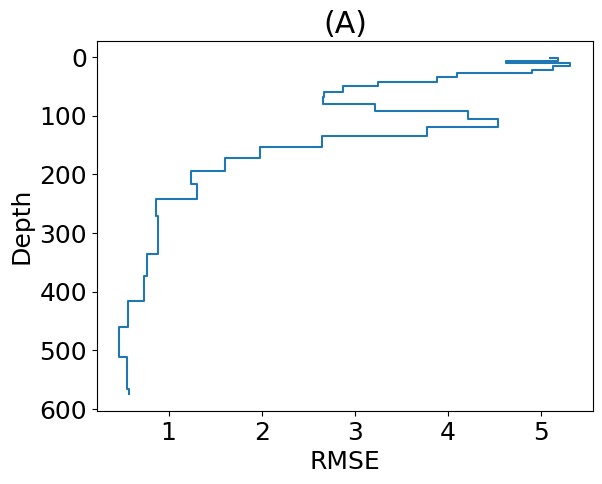

In [129]:
plt.plot(layer_rmse[:-2],plot_depths[:-2], drawstyle='steps-post')
plt.gca().invert_yaxis()
plt.title('(A)')
plt.xlabel('RMSE')
plt.ylabel('Depth')
plt.show()

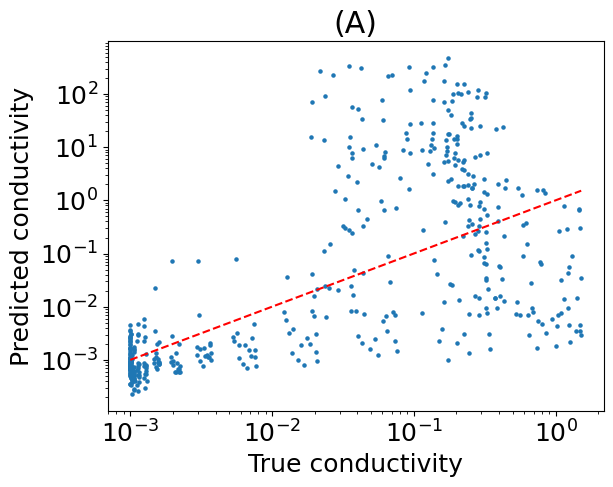

In [130]:
true_test1_flat = true_test1.flatten()
pred_test1_flat = zmd2_logs.flatten()
plt.scatter(np.exp(true_test1_flat[:-2]), np.exp(pred_test1_flat[:-2]), s=5)

plt.plot([np.exp(true_test1.min()), np.exp(true_test1.max())],
         [np.exp(true_test1.min()), np.exp(true_test1.max())],
         'r--')
plt.xscale('log')
plt.yscale('log')

plt.xlabel("True conductivity")
plt.ylabel("Predicted conductivity")

plt.title('(A)')

# plt.legend()
plt.show()

In [131]:
true_models2 = np.squeeze(true_test1)

mean_cond2 = np.mean(zmd2_logs,axis=0)
# mean_true_cond2 = np.mean(true_models2, axis=0)
std_cond = np.std(zmd2_logs,axis=0)
# print(std_cond)
# print(mean_cond2)

# mae2_log = mean_absolute_error(true_models2, zmd2_logs)
# mse2_log = mean_squared_error(true_models2, zmd2_logs)

# mae2_linear = mean_absolute_error(np.exp(true_models2), np.exp(zmd2_logs))
# mse2_linear = mean_squared_error(np.exp(true_models2), np.exp(zmd2_logs))

# percent_error2 = mean_absolute_percentage_error(np.exp(true_models2), np.exp(zmd2_logs))

# print(mae2_log, mse2_log)
# print(mae2_linear, mse2_linear)
# print(percent_error2)

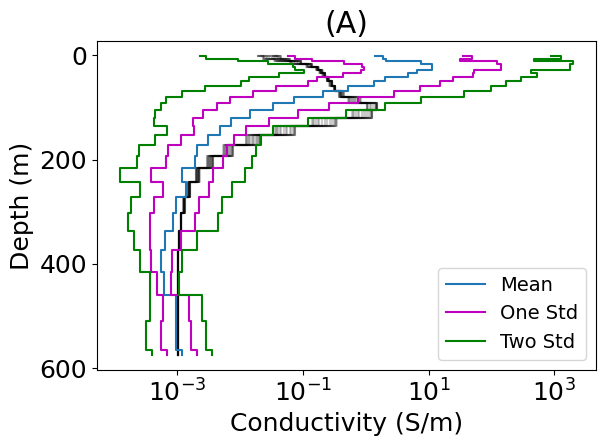

In [132]:
fig, ax = plt.subplots()
for log in true_models2:
    ax.plot(np.exp(log[:-2]), plot_depths[:-2],drawstyle='steps-post', c='k', alpha=0.2)
ax.plot(np.exp(mean_cond2[:-2]), plot_depths[:-2], drawstyle='steps-post',label='Mean')
ax.plot(np.exp(mean_cond2[:-2]+std_cond[:-2]),plot_depths[:-2], drawstyle='steps-post', c='m', label="One Std")
ax.plot(np.exp(mean_cond2[:-2]-std_cond[:-2]), plot_depths[:-2], drawstyle='steps-post', c='m')
ax.plot(np.exp(mean_cond2[:-2]+2*std_cond[:-2]), plot_depths[:-2], drawstyle='steps-post', c='g', label= 'Two Std') # type: ignore
ax.plot(np.exp(mean_cond2[:-2]-2*std_cond[:-2]), plot_depths[:-2], drawstyle='steps-post', c='g')
# ax.plot(true_test1[1],plot_depths, c='orange', label = 'True Mean')
ax.invert_yaxis()
ax.axes.set_xlabel("Conductivity (S/m)")
ax.axes.set_ylabel("Depth (m)")
ax.axes.set_xscale('log')
# ax.axes.set_xlim(1e-1, 1e3)
ax.axes.set_title('(A)')
ax.axes.legend(fontsize=14)

plt.tight_layout()
plt.savefig('Preliminary_generated_plots_mean&2std.jpg')
plt.show()



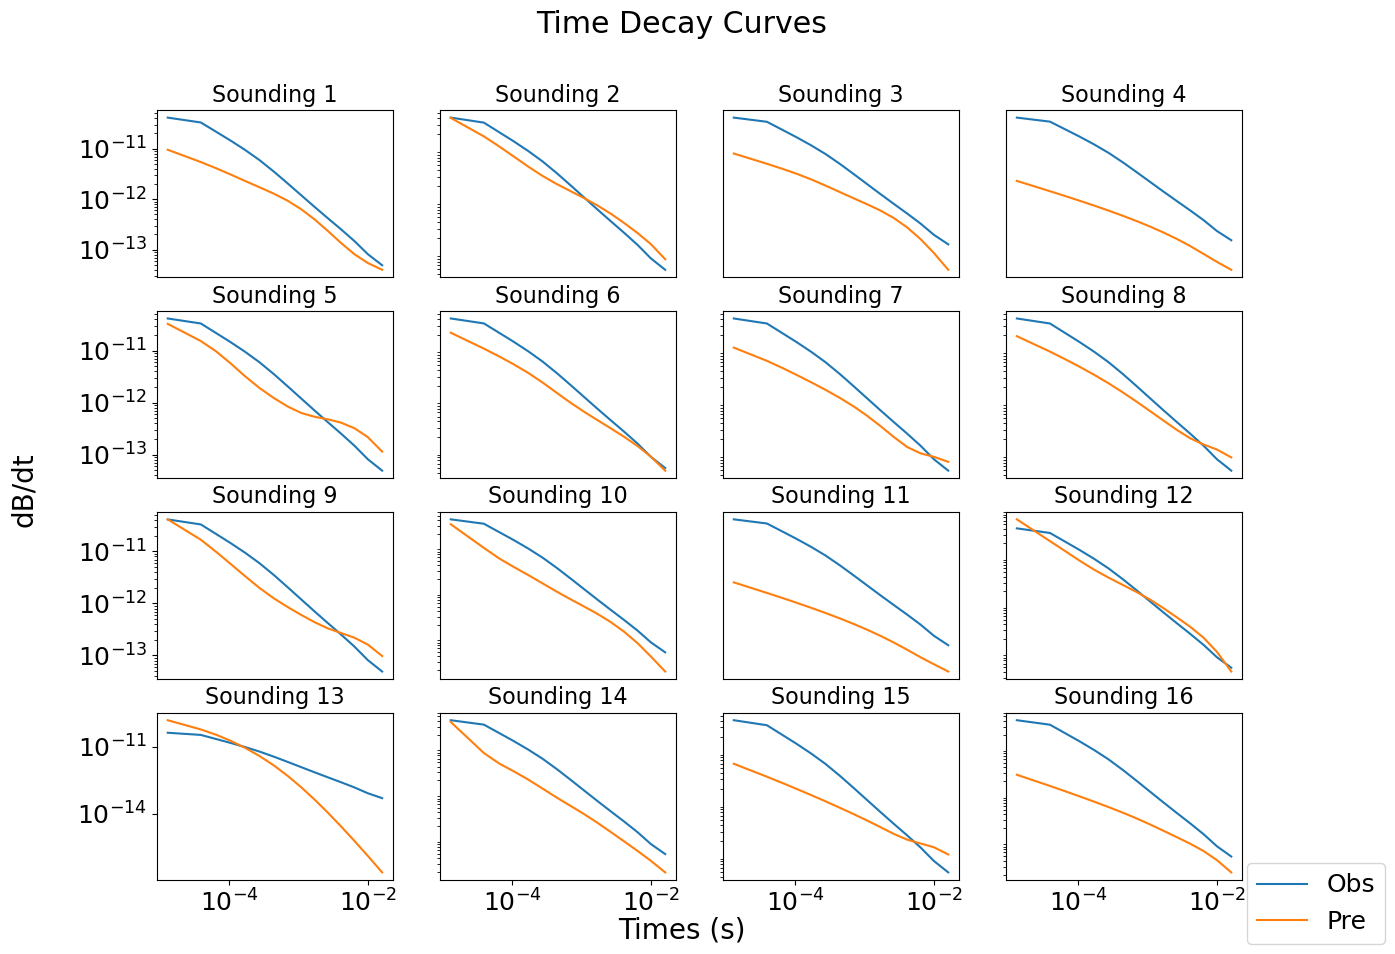

In [133]:
network.plot_data(latent=zmd2)

d_obs: (16, 16)
d_pre: (16, 16)
data_std: (1, 32, 1)
n_time: 16
d_std: (1, 16)
data tf.Tensor(
[[-7.60238633e-14 -3.50550101e-13 -6.11985994e-13 -6.15316446e-13
  -4.61444685e-13 -2.77831957e-13 -1.23426253e-13 -3.84413875e-14
  -3.01875851e-15 -1.00260300e-14 -1.48863347e-14 -1.60476050e-14
  -1.34270324e-14 -7.19376273e-15 -3.00038403e-15 -3.49013912e-15]
 [-1.31635209e-15 -1.91211034e-13 -3.52583875e-13 -3.81193774e-13
  -3.03661284e-13 -1.85321309e-13 -7.41243072e-14 -1.57395696e-14
  -1.46249728e-16 -4.49433183e-15 -1.33215447e-14 -1.88272995e-14
  -2.05212265e-14 -1.91054871e-14 -9.53508546e-15 -1.10611602e-14]
 [-8.41793947e-14 -3.74628388e-13 -6.59867614e-13 -6.68782358e-13
  -5.09690218e-13 -3.17853518e-13 -1.51128499e-13 -5.10689073e-14
  -4.19863941e-15 -1.34298192e-14 -1.79024242e-14 -1.80755086e-14
  -1.66860527e-14 -1.34416768e-14 -1.19142231e-14 -1.38391673e-14]
 [-9.57907392e-14 -4.10444465e-13 -7.35700671e-13 -7.58166479e-13
  -5.88285930e-13 -3.74570465e-13 -1.8442249

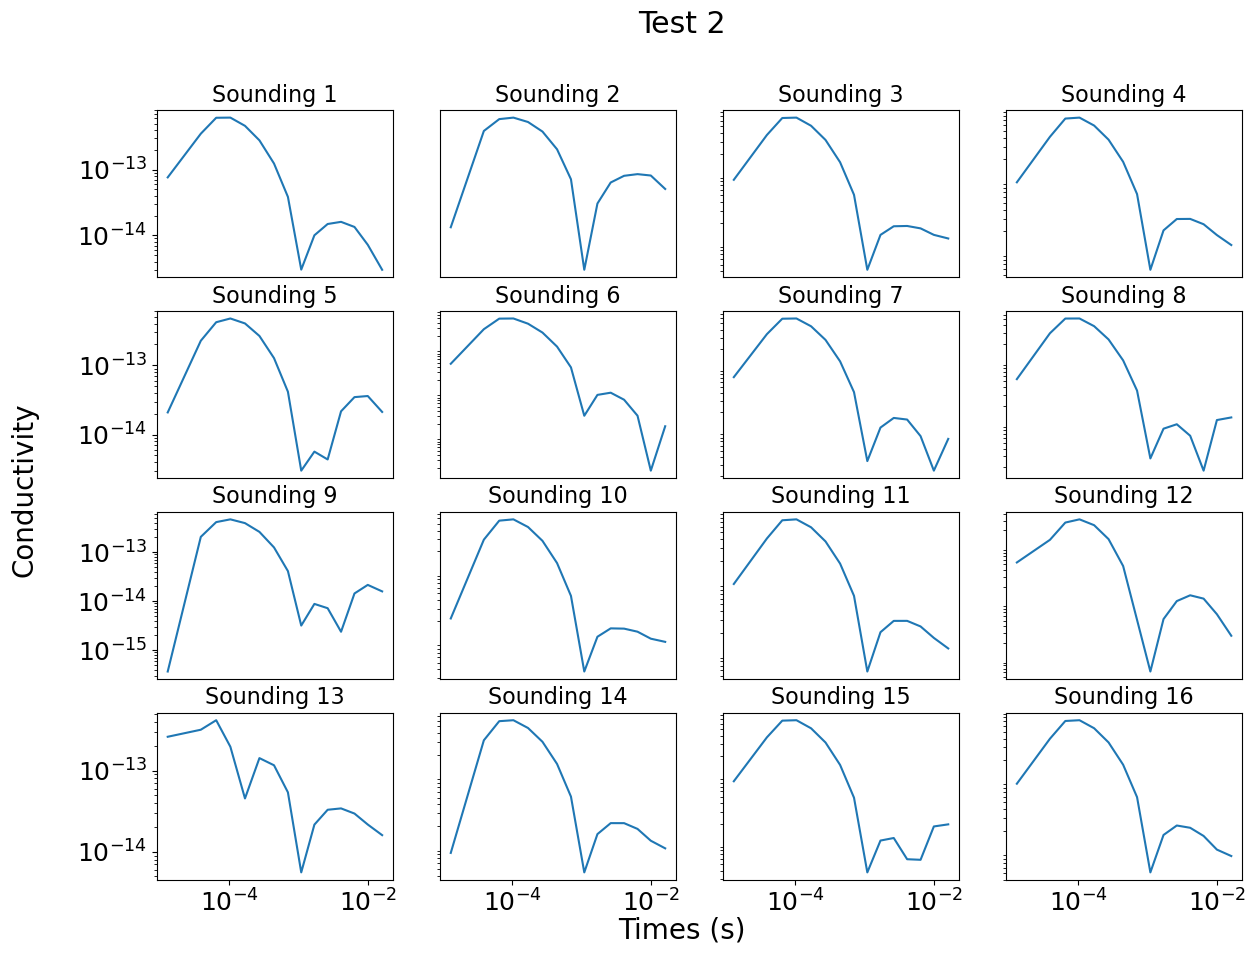

In [134]:
network.plot_residuals(latent=zmd2, weighted=True, step=14)

# Sample latent & different data soundings

In [106]:
# Plot true models for comparisons - need models for line 94 and adjust plot_logs to show true models too

data_batch = raw_test_data94[0:16]
data_batch_all = raw_test_data94
print(data_batch_all.shape)
latent_dim = 20  # known from model
latent_input = tf.random.normal((16, latent_dim))
latent_input_all = tf.random.normal((5748, latent_dim))

(5748, 16)


In [107]:
zmd3 = tf.concat(((latent_input), data_batch), -1)
zmd3_all = tf.concat(((latent_input_all), data_batch_all), -1)
print(zmd3.shape)
print(zmd3_all.shape)

(16, 36)
(5748, 36)


In [108]:
zmd3_tanhs = network.decode(zmd3, apply_tanh=True)
zmd3_samples = zmd3_tanhs.shape[0]
zmd3_tanhs = np.reshape(zmd3_tanhs, (zmd3_samples, network.n_model))
zmd3_logs = network.tanhs_to_model(zmd3_tanhs)
# zmd3_exp = (10**zmd3_logs)

zmd3_tanhs_all = network.decode(zmd3_all, apply_tanh=True)
zmd3_samples_all = zmd3_tanhs_all.shape[0]
zmd3_tanhs_all = np.reshape(zmd3_tanhs_all, (zmd3_samples_all, network.n_model))
zmd3_logs_all = network.tanhs_to_model(zmd3_tanhs_all)

In [109]:
true_models = x_test94[0:5748]
print(true_models.shape)
true_logs = network.tanhs_to_model(true_models)
true_models = np.exp(true_logs)
# print(true_logs[100])

(5748, 32, 1)


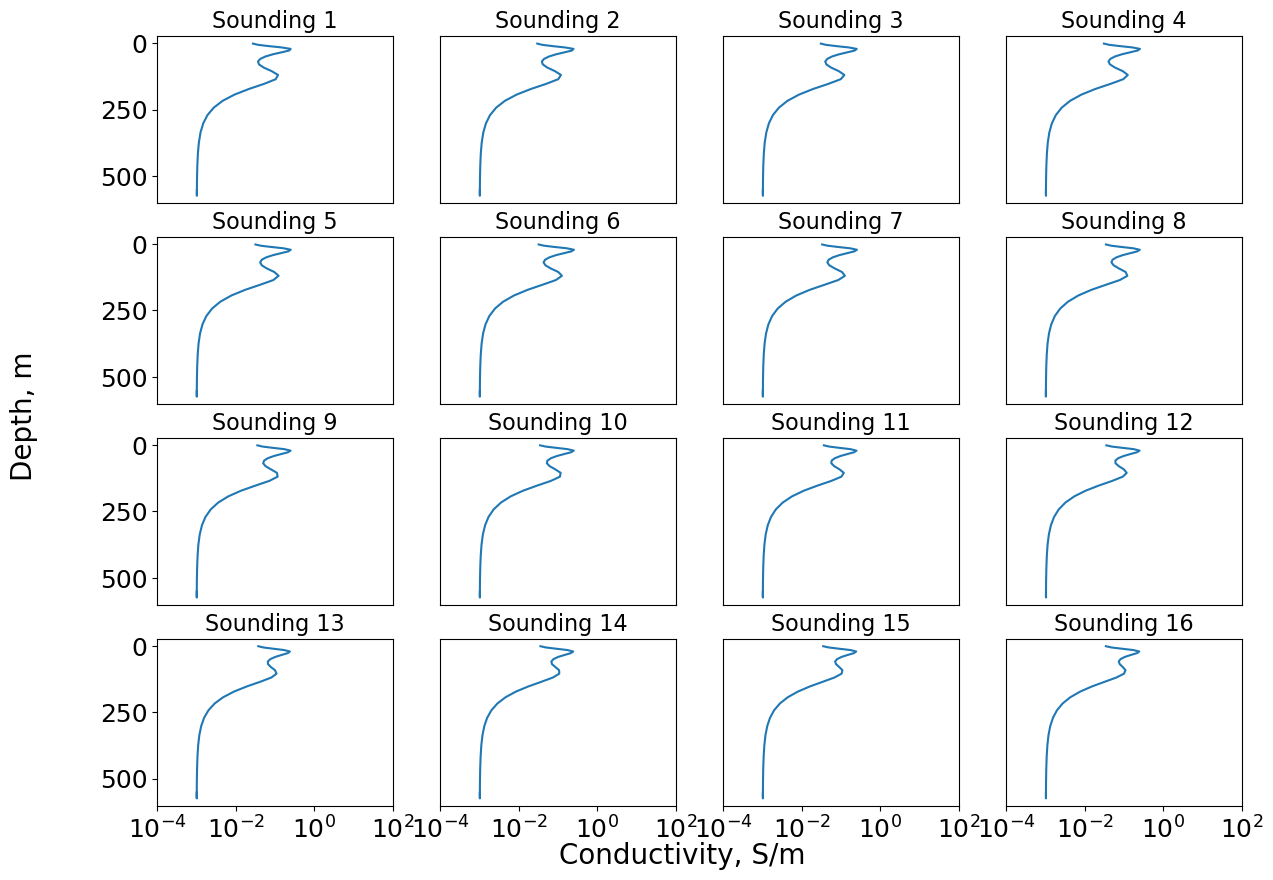

In [110]:
vae.plot_logs(true_models[0:16], depths=depths)

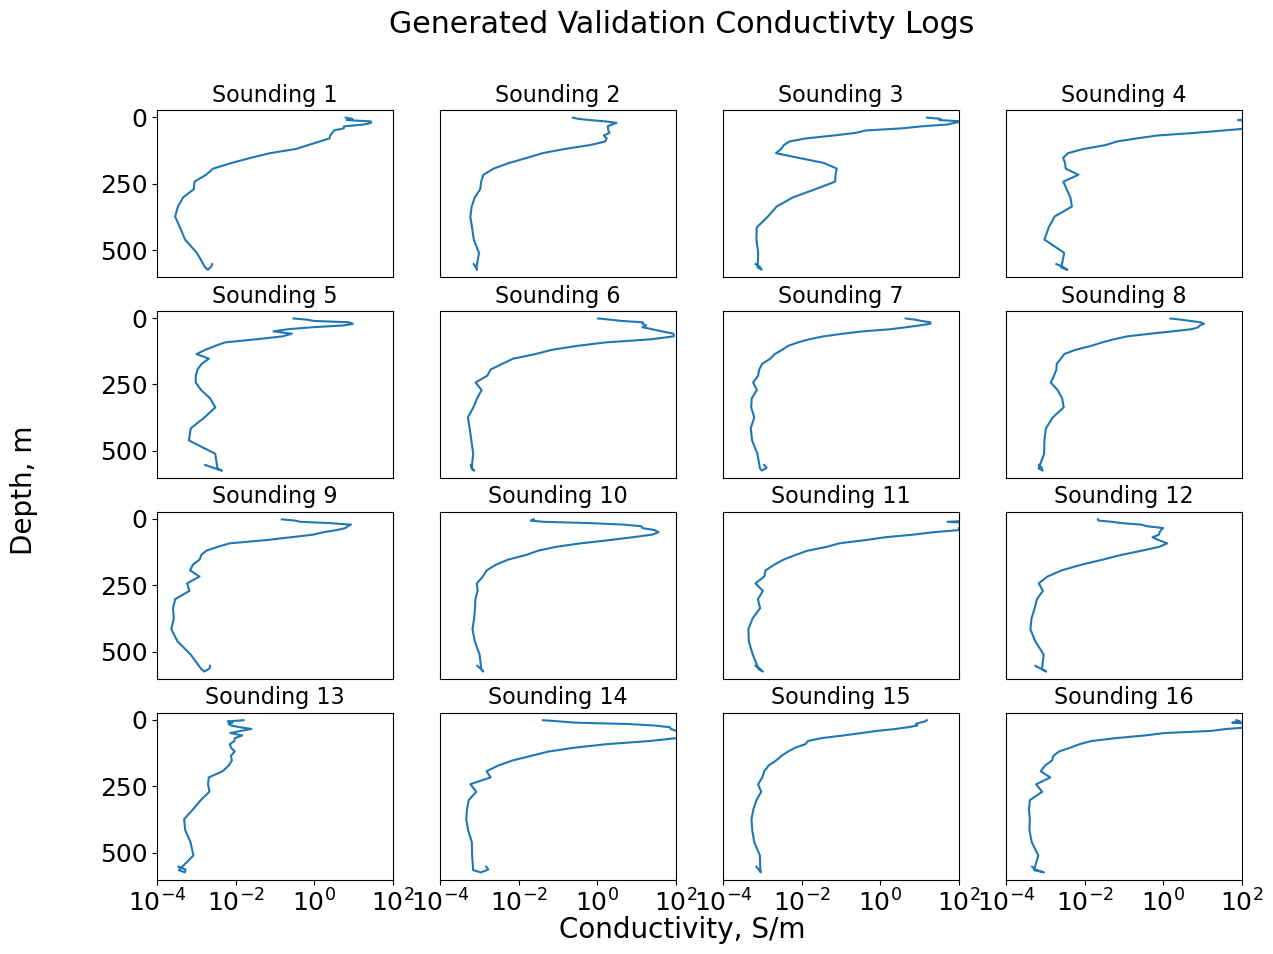

In [111]:
network.plot_models(latent=zmd3)

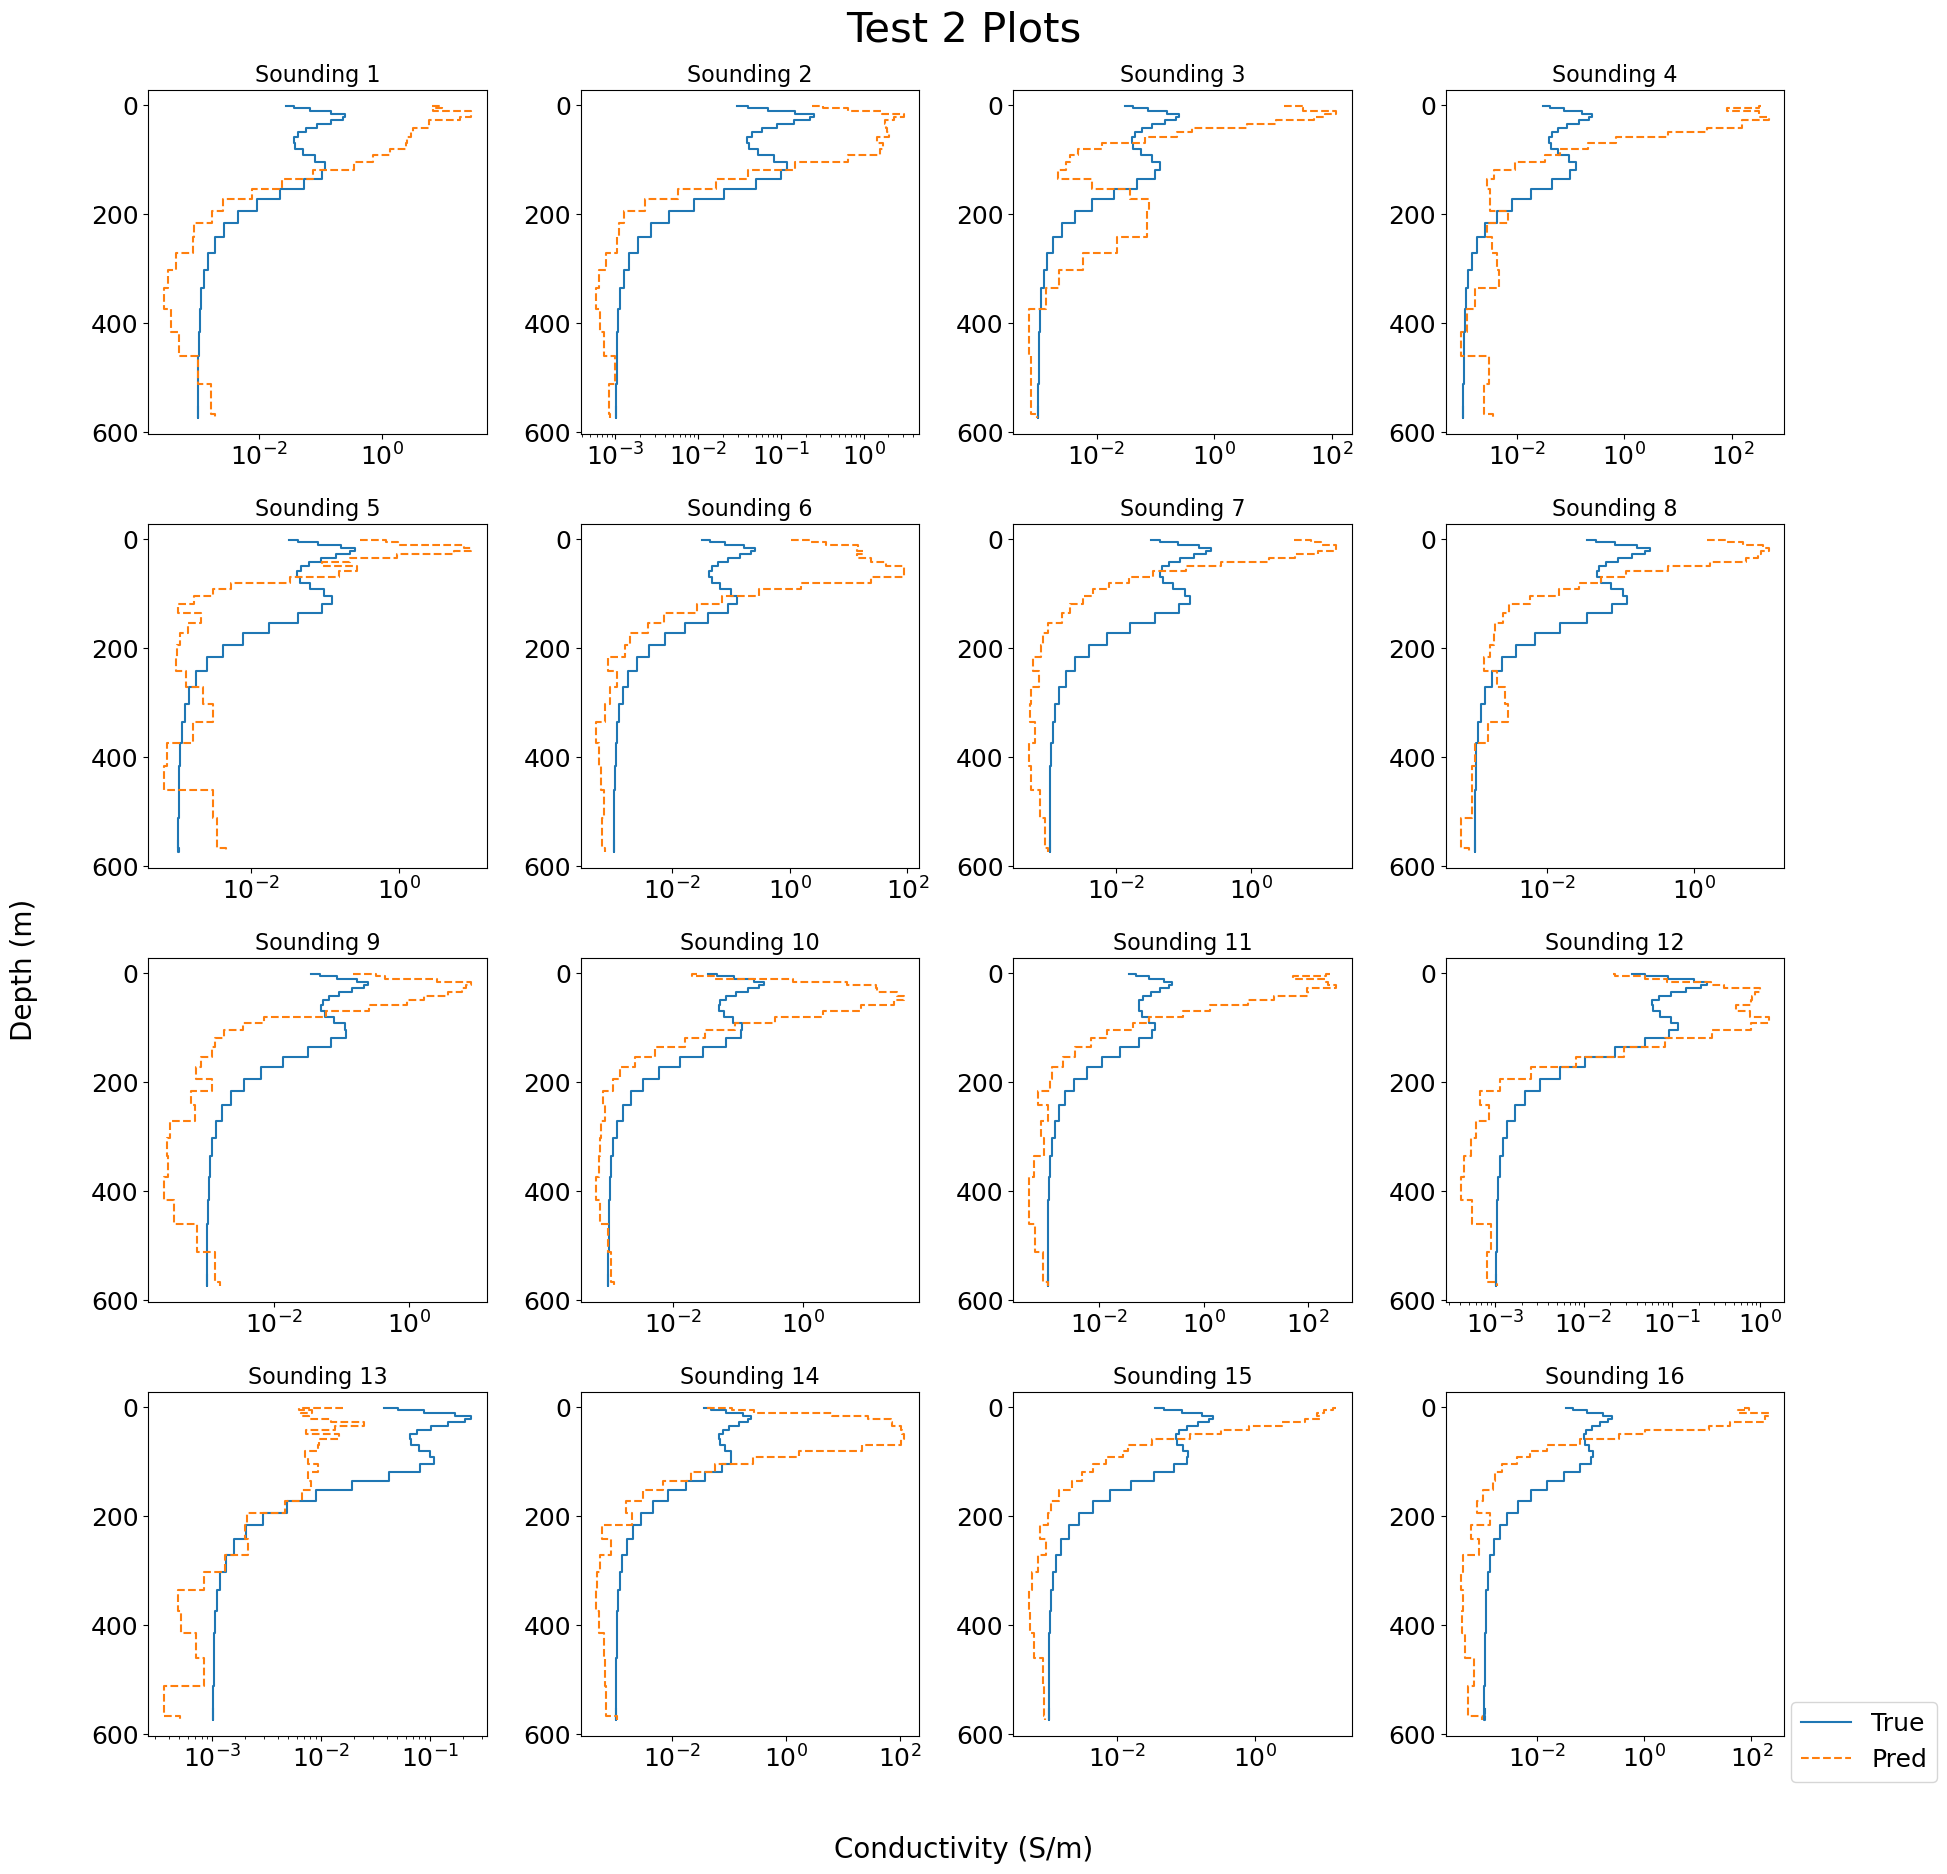

In [112]:
# plt.figure(figsize=(20, 20))

# for i in range(16):
#     plt.subplot(4, 4, i + 1)
#     plt.plot(true_logs[i][:-2], plot_depths[:-2], drawstyle='steps-post', label='True')
#     plt.plot(np.exp(zmd3_logs[i])[:-2], plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
#     plt.xscale('log')
#     plt.gca().invert_yaxis()
#     if i == 0:
#         plt.legend()
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 20))
# samples = data.shape[0]
subplot_rows = 4
subplot_cols = 4
for i in range(16):
        ax = plt.subplot(subplot_rows, subplot_cols, i+1)
        ax.set_title('Sounding %d' %int(i+1), fontsize = 16)
        ax.semilogx(np.exp(true_logs[i]), plot_depths, drawstyle='steps-post', label='True')
        ax.semilogx(np.exp(zmd3_logs[i][:-2]), plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
        plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
             rotation='vertical', size=20)
plt.suptitle('Test 2 Plots',fontsize = 30)
plt.tight_layout(rect=(0.05,0.08,1,1))
plt.show()

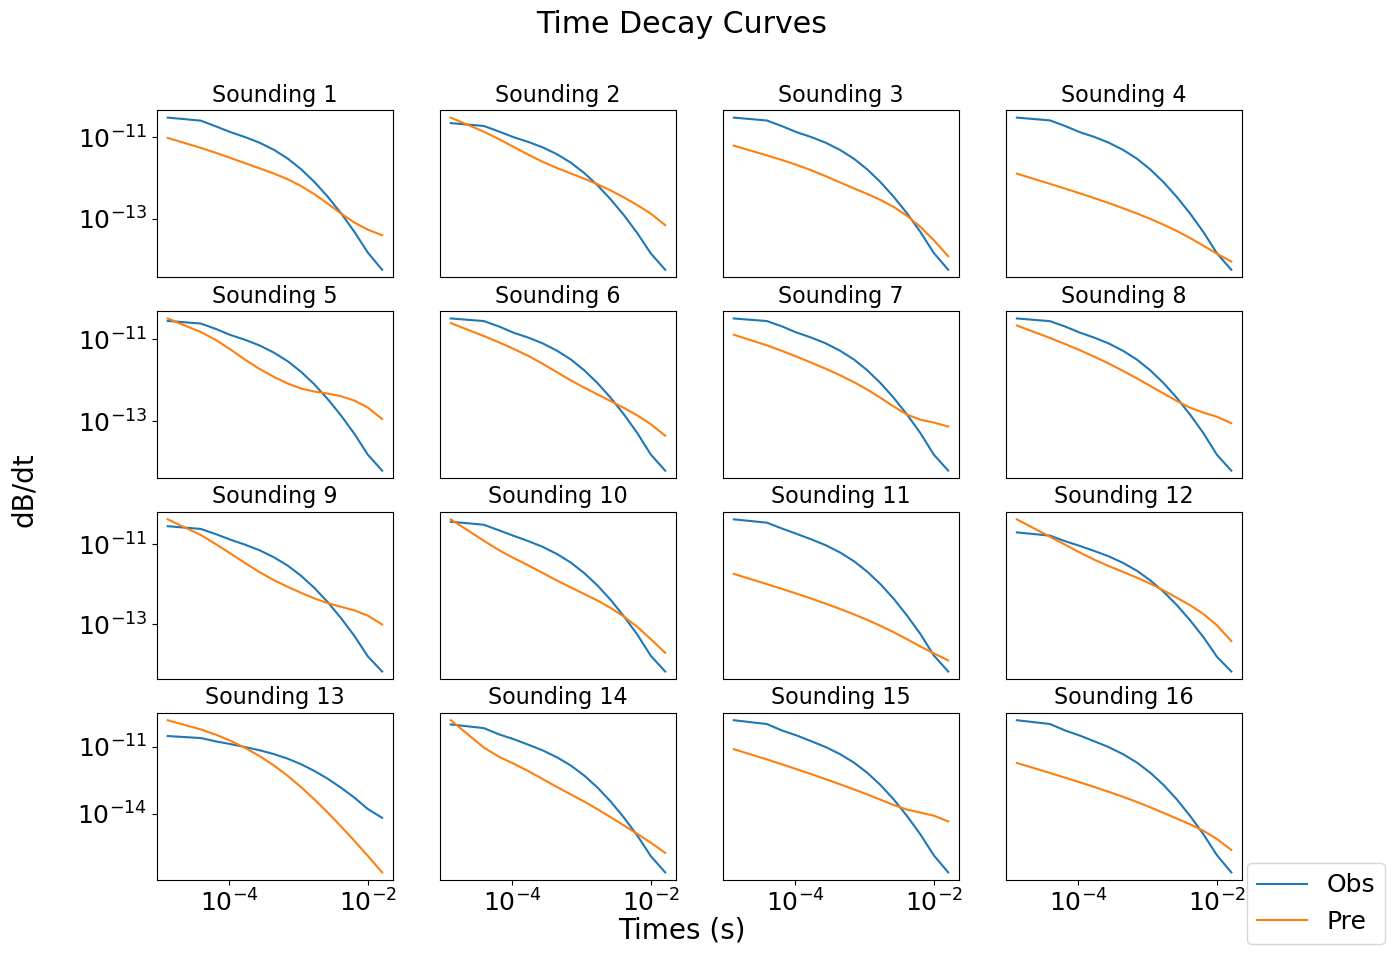

In [113]:
network.plot_data(latent=zmd3)
# Why only one sounding???

In [114]:
# zmd3_tanhs = network.decode(zmd3, apply_tanh=True)
# zmd3_samples = zmd3_tanhs.shape[0]
# zmd3_tanhs = np.reshape(zmd3_tanhs, (zmd3_samples, network.n_model))
# zmd3_logs = np.exp(network.tanhs_to_model(zmd3_tanhs))
# zmd3_exp = (10**zmd3_logs)

d_obs: (16, 16)
d_pre: (16, 16)
data_std: (1, 32, 1)
n_time: 16
d_std: (1, 16)
data tf.Tensor(
[[-4.87279725e-14 -2.50422513e-13 -4.89460686e-13 -5.43263351e-13
  -4.94993044e-13 -3.65837433e-13 -1.99079631e-13 -7.06631815e-14
  -5.30731744e-15 -1.30260301e-14 -9.07133747e-15 -2.41620198e-16
  -6.62609268e-15 -1.05235899e-14 -1.12042088e-14 -1.30069007e-14]
 [-2.66617020e-14 -8.93551522e-14 -2.28108087e-13 -3.02918877e-13
  -3.34413486e-13 -2.70851565e-13 -1.48249631e-13 -4.75536934e-14
  -2.41602511e-15 -1.53209488e-15 -1.91308642e-14 -3.45609670e-14
  -4.05157136e-14 -3.67989839e-14 -2.36938002e-14 -2.75049165e-14]
 [-5.53030386e-14 -2.70591926e-13 -5.34052240e-13 -5.84793878e-13
  -5.37729637e-13 -4.01064544e-13 -2.23755435e-13 -8.24842852e-14
  -6.44815012e-15 -1.63500754e-14 -1.20960582e-14 -2.39898704e-15
  -3.24661715e-15 -4.22722846e-15 -2.19882934e-15 -2.55155673e-15]
 [-6.59300902e-14 -3.03945129e-13 -6.08798710e-13 -6.69522597e-13
  -6.13727439e-13 -4.55610593e-13 -2.5560445

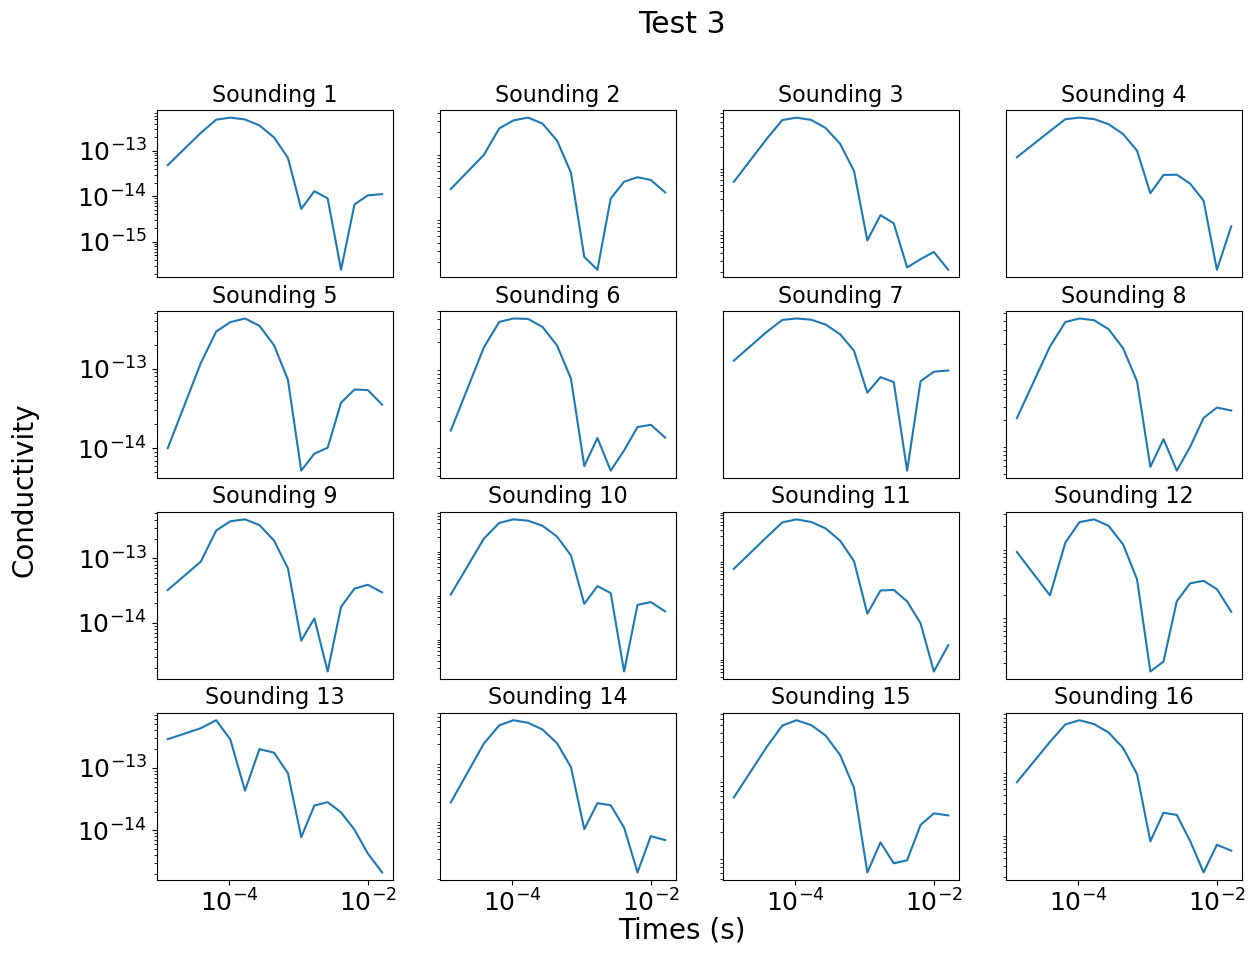

In [115]:
network.plot_residuals(latent=zmd3, step=13)

In [116]:
true_models3 = np.squeeze(true_logs)
true_models3 = true_models3[0:16,]

model_rmse3 = rmse(zmd3_logs, true_models3)
model_mae3 = mae(zmd3_logs, true_models3)
model_r23 = r2_score(zmd3_logs.flatten(), true_models3.flatten())

layer_rmse3 = np.sqrt(np.mean((zmd3_logs- true_models3) ** 2, axis=0))

print("Layer-wise RMSE shape:", layer_rmse3)  # (32,)

print("Model RMSE:", model_rmse3)
print("Model MAE:", model_mae3)
print("Model R2:", model_r23)

Layer-wise RMSE shape: [4.9520927  4.9684805  4.24650201 4.72511562 4.56488967 4.6946697
 4.35287006 4.5783083  4.23078269 4.04101669 3.53877546 2.93714969
 2.38645752 2.36192637 2.63172883 2.65192094 2.09955803 1.74544709
 1.5287796  1.20964256 1.30141078 0.8590977  0.90833165 0.90822042
 0.81159532 0.7744717  0.59885202 0.47717909 0.56186168 0.56454614
 0.55175963 0.58450274]
Model RMSE: 2.9124130878779986
Model MAE: 2.1085452711205592
Model R2: 0.49073382596678905


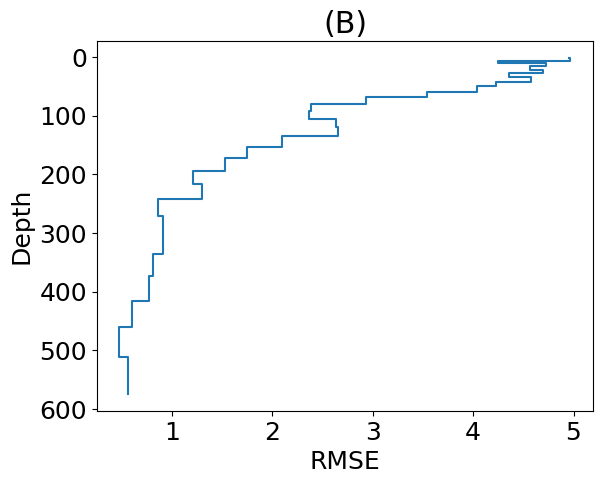

In [117]:
plt.plot(layer_rmse3[:-2],plot_depths[:-2], drawstyle='steps-post')
plt.gca().invert_yaxis()
plt.title('(B)')
plt.xlabel('RMSE')
plt.ylabel('Depth')
plt.show()

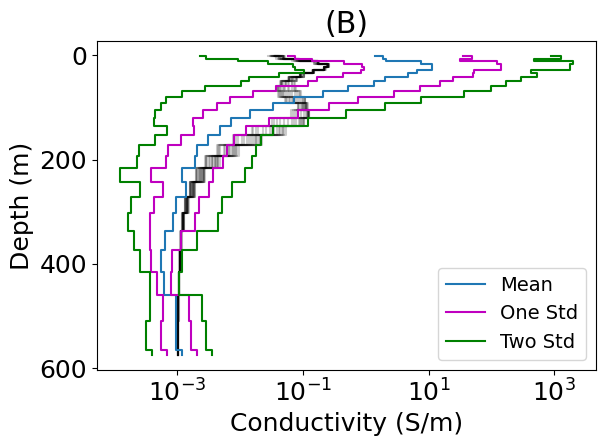

In [118]:
mean_cond3 = np.mean(zmd3_logs,axis=0)
# mean_true_cond2 = np.mean(true_models2, axis=0)
std_cond3 = np.std(zmd3_logs,axis=0)

fig, ax = plt.subplots()
for log in true_models3:
    ax.plot(np.exp(log[:-2]), plot_depths[:-2],drawstyle='steps-post', c='k', alpha=0.2)
ax.plot(np.exp(mean_cond3[:-2]), plot_depths[:-2], drawstyle='steps-post',label='Mean')
ax.plot(np.exp(mean_cond3[:-2]+std_cond3[:-2]),plot_depths[:-2], drawstyle='steps-post', c='m', label="One Std")
ax.plot(np.exp(mean_cond3[:-2]-std_cond3[:-2]), plot_depths[:-2], drawstyle='steps-post', c='m')
ax.plot(np.exp(mean_cond3[:-2]+2*std_cond3[:-2]), plot_depths[:-2], drawstyle='steps-post', c='g', label= 'Two Std') # type: ignore
ax.plot(np.exp(mean_cond3[:-2]-2*std_cond3[:-2]), plot_depths[:-2], drawstyle='steps-post', c='g')
# ax.plot(true_test1[1],plot_depths, c='orange', label = 'True Mean')
ax.invert_yaxis()
ax.axes.set_xlabel("Conductivity (S/m)")
ax.axes.set_ylabel("Depth (m)")
ax.axes.set_xscale('log')
# ax.axes.set_xlim(1e-1, 1e3)
ax.axes.set_title('(B)')
ax.axes.legend(fontsize=14)

plt.tight_layout()
plt.savefig('Preliminary_generated_plots_mean&2std.jpg')
plt.show()

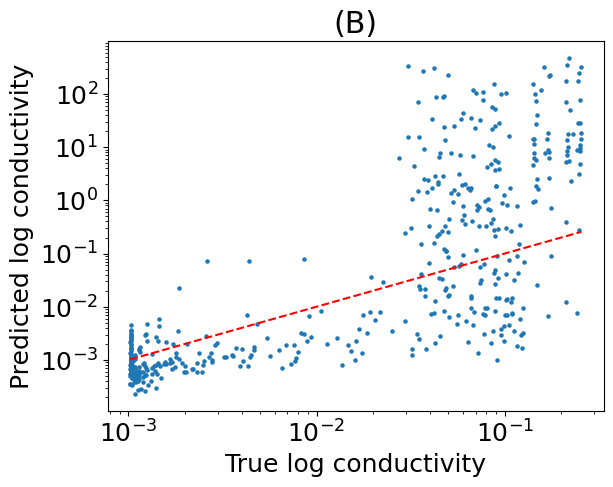

In [119]:
true_test2_flat = true_models3.flatten()
pred_test2_flat = zmd3_logs.flatten()
plt.scatter(np.exp(true_test2_flat[:-2]), np.exp(pred_test2_flat[:-2]), s=5)

plt.plot([np.exp(true_models3.min()), np.exp(true_models3.max())],
         [np.exp(true_models3.min()), np.exp(true_models3.max())],
         'r--')
plt.xscale('log')
plt.yscale('log')

plt.xlabel("True log conductivity")
plt.ylabel("Predicted log conductivity")

plt.title('(B)')

# plt.legend()
plt.show()

In [120]:
# Trim everything consistently
true_section_3 = true_logs[:, :-2]
pred_section_3 = zmd3_logs_all[:, :-2]
# depths_2d = plot_depths[:-2]

# Transpose → (depth, distance)
true_section_3 = true_section_3.T
true_section_3 = np.squeeze(true_section_3)
pred_section_3 = pred_section_3.T
pred_section_3 = np.squeeze(pred_section_3)

nx_3 = true_section_3.shape[1]
x_3 = np.arange(nx_3)   # or real station distances if you have them

X_3, Z_3 = np.meshgrid(x_3, depths_2d)
print(X_3.shape,Z_3.shape)

(30, 5748) (30, 5748)


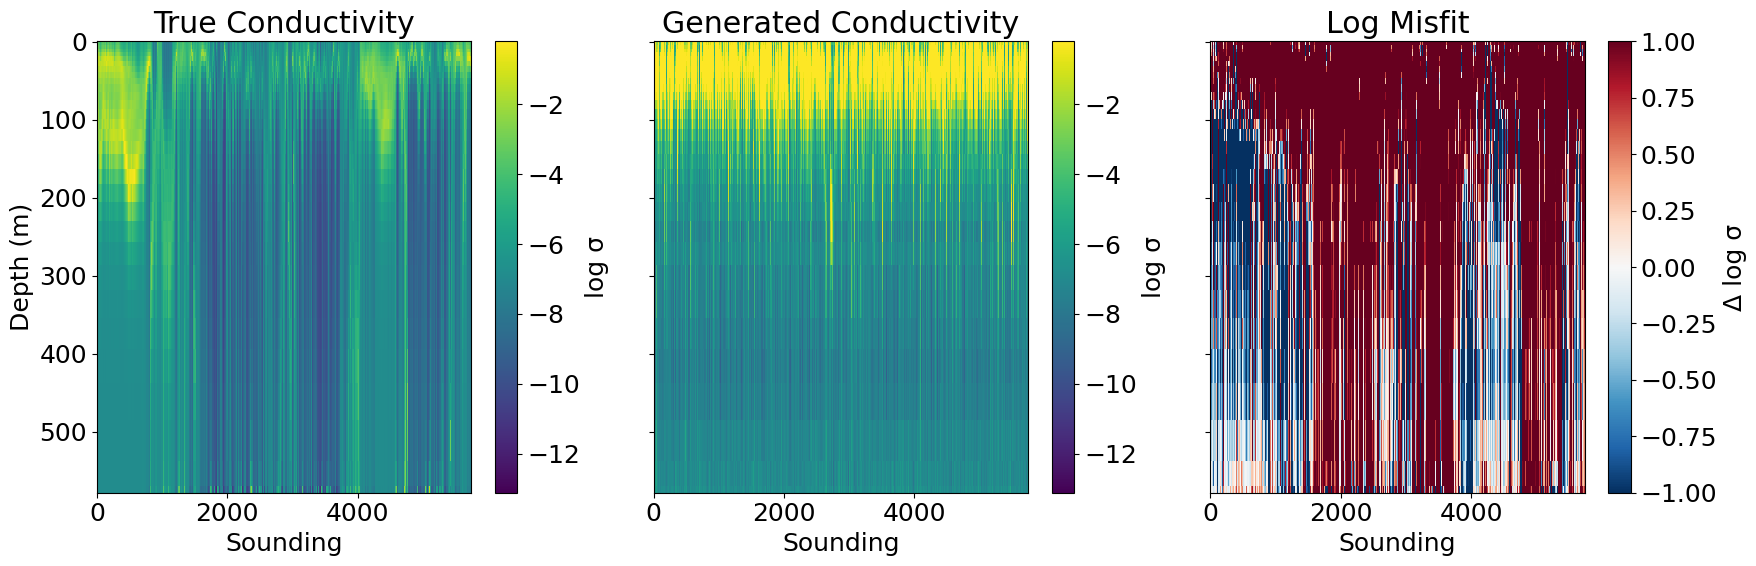

In [121]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Use same color limits for fair comparison
vmin = np.min(true_section_3)
vmax = np.max(true_section_3)

# TRUE
im0 = axs[0].pcolormesh(X_3, Z_3, true_section_3,
                        shading='auto', cmap='viridis',
                        vmin=vmin, vmax=vmax)
axs[0].set_title('True Conductivity')

# PREDICTED
im1 = axs[1].pcolormesh(X_3, Z_3, pred_section_3,
                        shading='auto', cmap='viridis',
                        vmin=vmin, vmax=vmax)
axs[1].set_title('Generated Conductivity')

# MISFIT (log difference)
misfit = pred_section_3 - true_section_3

im2 = axs[2].pcolormesh(X_3, Z_3, misfit,
                        shading='auto', cmap='RdBu_r',
                        vmin=-1, vmax=1)  # adjustable
axs[2].set_title('Log Misfit')

# Formatting
for ax in axs:
    ax.invert_yaxis()
    ax.set_xlabel('Sounding')

axs[0].set_ylabel('Depth (m)')

# Colorbars
fig.colorbar(im0, ax=axs[0], label='log σ')
fig.colorbar(im1, ax=axs[1], label='log σ')
fig.colorbar(im2, ax=axs[2], label='Δ log σ')

plt.tight_layout()
plt.show()

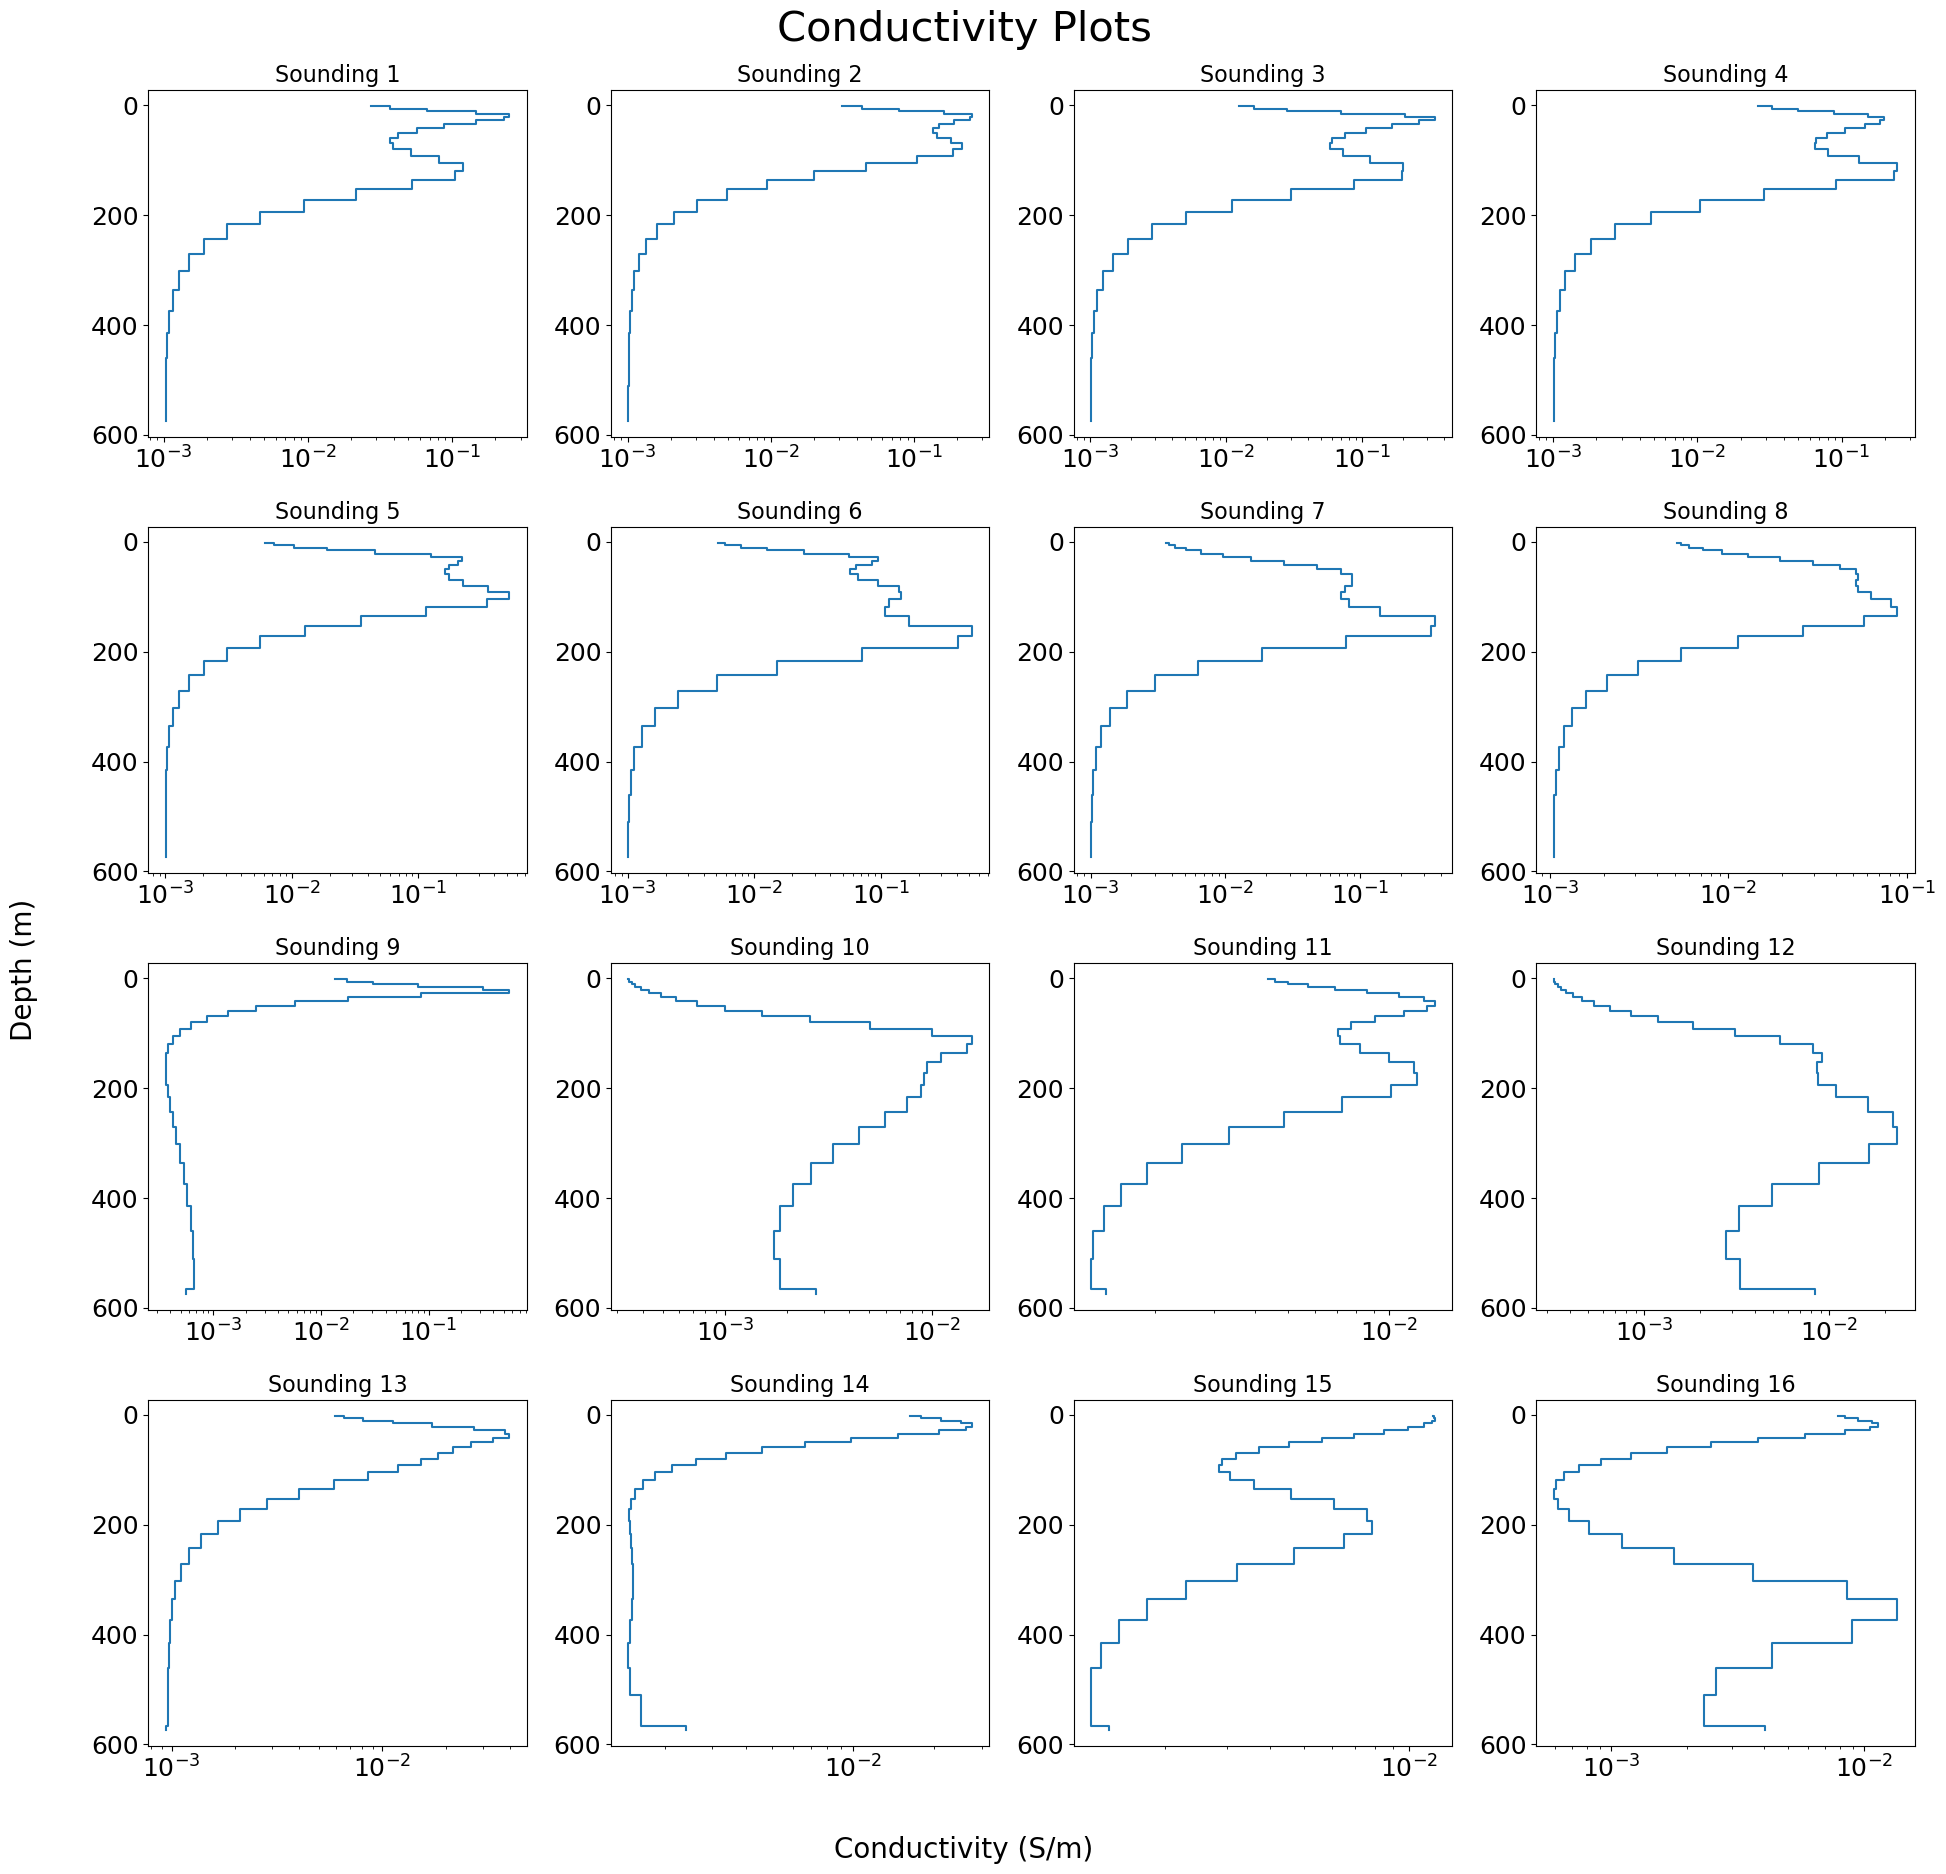

In [122]:
# plt.figure(figsize=(20, 20))

array1 = np.array(range(0,1600,100))
# print(array1)

# print(true_logs.shape)
# for i in range(len(array1)):
#     j = array1[i]
#     plt.subplot(4, 4,  i+1)
#     plt.plot(true_logs[j][:-2], plot_depths[:-2], drawstyle='steps-post')
#     plt.xscale('log')
#     plt.gca().invert_yaxis()
#     # if i == 0:
#     #     plt.legend()
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 20))
# samples = data.shape[0]
subplot_rows = 4
subplot_cols = 4
for i in range(len(array1)):
        j = array1[i]
        ax = plt.subplot(subplot_rows, subplot_cols, i+1)
        ax.set_title('Sounding %d' %int(i+1), fontsize = 16)
        ax.semilogx(np.exp(true_logs[j][:-2]), plot_depths[:-2], drawstyle='steps-post', label='True')
        plt.gca().invert_yaxis()
# plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
             rotation='vertical', size=20)
plt.suptitle('Conductivity Plots',fontsize = 30)
plt.tight_layout(rect=(0.05,0.08,1,1))
plt.show()